In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import networkx as nx
from tabulate import tabulate
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

from utils.paths import get_experiment_paths
from datasets.sachs import get_structural_equations_sachs, graph_sachs

# Rutas del experimento, identicas a las usadas por sachs_hsic_beta_nonadditive.ipynb al guardar
paths = get_experiment_paths('sachs_hsic_nonadditive')
results_bdir = str(paths.root)
images_dir = str(paths.images)
samples_dir = str(paths.samples)
figures_dir = str(paths.figures)
data_dir = str(paths.data)

model_names = ['kan', 'kaam', 'kan_hsic', 'kaam_hsic', 'dbcm', 'flow']
betas = [round(0.1 * i, 1) for i in range(1, 9)]  # 0.1 .. 0.8
beta_sweep_seeds = np.array([42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
                              52, 53, 54, 55, 56, 57, 58, 59, 60, 61])

structural_equations = get_structural_equations_sachs()

factual_eval = pd.read_csv(os.path.join(data_dir, 'sachs_factual_eval.csv'))

with open(os.path.join(data_dir, 'sachs_interventions_eval.pkl'), 'rb') as f:
    inter_vector = pickle.load(f)

cf_min_val, cf_max_val, cf_step = -3, 3, 0.1
cf_vector_values = np.arange(cf_min_val, cf_max_val, cf_step)

# Resultados del barrido de beta (guardados por familia en sachs_hsic_beta.ipynb)
beta_sweep_results = {}
beta_sweep_results_por_semilla = {}
beta0_sweep_results_por_semilla = {}
for family in ['kan', 'kaam']:
    with open(os.path.join(data_dir, f"sachs_beta_sweep_{family}.pkl"), 'rb') as f:
        beta_sweep_results[family] = pickle.load(f)
    with open(os.path.join(data_dir, f"sachs_beta_sweep_{family}_por_semilla.pkl"), 'rb') as f:
        beta_sweep_results_por_semilla[family] = pickle.load(f)
    with open(os.path.join(data_dir, f"sachs_beta0_sweep_{family}_por_semilla.pkl"), 'rb') as f:
        beta0_sweep_results_por_semilla[family] = pickle.load(f)

# Beta optima por familia, recalculada a partir del barrido cargado (igual criterio que en sachs_hsic_beta.ipynb)
beta_opt = {family: min(betas, key=lambda b: beta_sweep_results[family][b]["rf_acc_obs"]) for family in ['kan', 'kaam']}


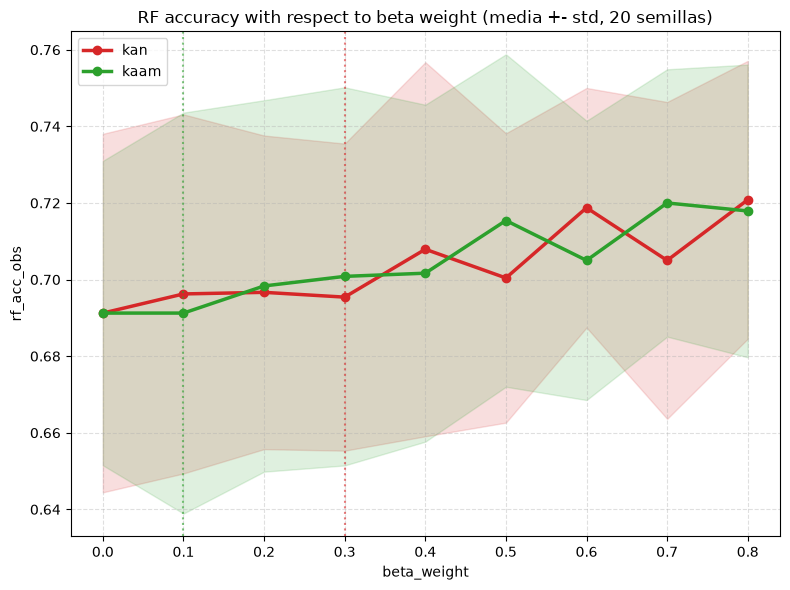

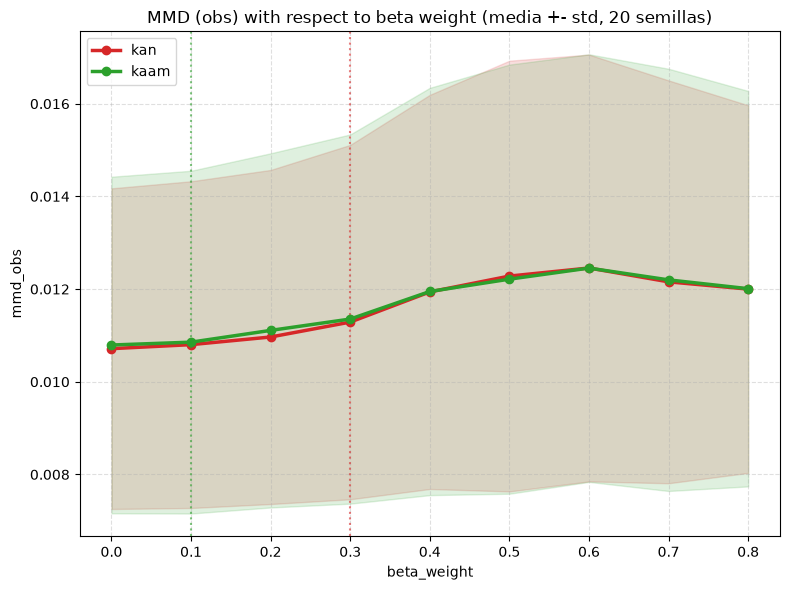

In [2]:
# Grafico del barrido de beta: media +- std de rf_acc_obs sobre las 20 semillas
# (beta_sweep_results_por_semilla / beta0_sweep_results_por_semilla, celda anterior),
# incluyendo el punto Beta=0 (MSE puro, tambien promediado sobre las mismas 20 semillas).
#
# Nota: los notebooks Ruido_Aditivo_*.ipynb usan un eje Y secundario para Beta=1 (HSIC
# puro) porque su valor puede diferir mucho en escala del resto del barrido. Aqui Beta=0
# (MSE puro) es el analogo "extremo" (el otro punto fuera del barrido hybrid), pero su
# rf_acc_obs esta en un rango similar al de Beta in [0.1, 0.8] (ver celda anterior), asi
# que no hace falta esa complejidad: un unico eje con banda de +-std es suficiente. Si al
# ejecutar esto con datos reales Beta=0 resulta tener una escala muy distinta, se puede
# anadir el mismo truco de eje secundario que en Ruido_Aditivo_*.ipynb.
paleta_familia = {"kan": "tab:red", "kaam": "tab:green"}
betas_con_cero = [0.0] + betas

fig, ax = plt.subplots(figsize=(8, 6))
for family, color in paleta_familia.items():
    valores0 = list(beta0_sweep_results_por_semilla[family].values())
    y_mean = [float(np.mean([v["rf_acc_obs"] for v in valores0]))]
    y_std = [float(np.std([v["rf_acc_obs"] for v in valores0]))]
    for b in betas:
        valores = list(beta_sweep_results_por_semilla[family][b].values())
        y_mean.append(float(np.mean([v["rf_acc_obs"] for v in valores])))
        y_std.append(float(np.std([v["rf_acc_obs"] for v in valores])))
    y_mean = np.array(y_mean)
    y_std = np.array(y_std)

    ax.plot(betas_con_cero, y_mean, marker="o", linewidth=2.5, label=family, color=color, markersize=6)
    ax.fill_between(betas_con_cero, y_mean - y_std, y_mean + y_std, alpha=0.15, color=color)
    ax.axvline(beta_opt[family], linestyle=":", color=color, alpha=0.6)

ax.set_xlabel("beta_weight")
ax.set_ylabel("rf_acc_obs")
ax.set_title(f"RF accuracy with respect to beta weight (media +- std, {len(beta_sweep_seeds)} semillas)")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xticks(betas_con_cero)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "sachs_rf_hsic_beta_sweep.pdf"), dpi=300, bbox_inches="tight")
plt.show()

# Mismo grafico pero para mmd_obs en vez de rf_acc_obs. mmd_obs esta guardado con el mismo
# esquema por semilla que rf_acc_obs (beta_sweep_results_por_semilla / beta0_sweep_results_por_semilla),
# asi que basta con repetir el mismo bucle cambiando la clave de la metrica.
#
# Nota: HSIC y dHSIC (utils/metrics.py) NO estan disponibles aqui -- el barrido de beta
# (sachs_hsic_beta.ipynb, celda "Barrido de beta") solo calculo y guardo mmd_obs y
# rf_acc_obs por semilla, nunca HSIC/dHSIC entre inputs y residuos. Para graficarlos habria
# que editar ese bucle de entrenamiento para calcularlos y volver a correr las 360
# combinaciones (familia x beta x semilla), no es un cambio de solo plotting.
fig, ax = plt.subplots(figsize=(8, 6))
for family, color in paleta_familia.items():
    valores0 = list(beta0_sweep_results_por_semilla[family].values())
    y_mean = [float(np.mean([v["mmd_obs"] for v in valores0]))]
    y_std = [float(np.std([v["mmd_obs"] for v in valores0]))]
    for b in betas:
        valores = list(beta_sweep_results_por_semilla[family][b].values())
        y_mean.append(float(np.mean([v["mmd_obs"] for v in valores])))
        y_std.append(float(np.std([v["mmd_obs"] for v in valores])))
    y_mean = np.array(y_mean)
    y_std = np.array(y_std)

    ax.plot(betas_con_cero, y_mean, marker="o", linewidth=2.5, label=family, color=color, markersize=6)
    ax.fill_between(betas_con_cero, y_mean - y_std, y_mean + y_std, alpha=0.15, color=color)
    ax.axvline(beta_opt[family], linestyle=":", color=color, alpha=0.6)

ax.set_xlabel("beta_weight")
ax.set_ylabel("mmd_obs")
ax.set_title(f"MMD (obs) with respect to beta weight (media +- std, {len(beta_sweep_seeds)} semillas)")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xticks(betas_con_cero)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "sachs_mmd_beta_sweep.pdf"), dpi=300, bbox_inches="tight")
plt.show()


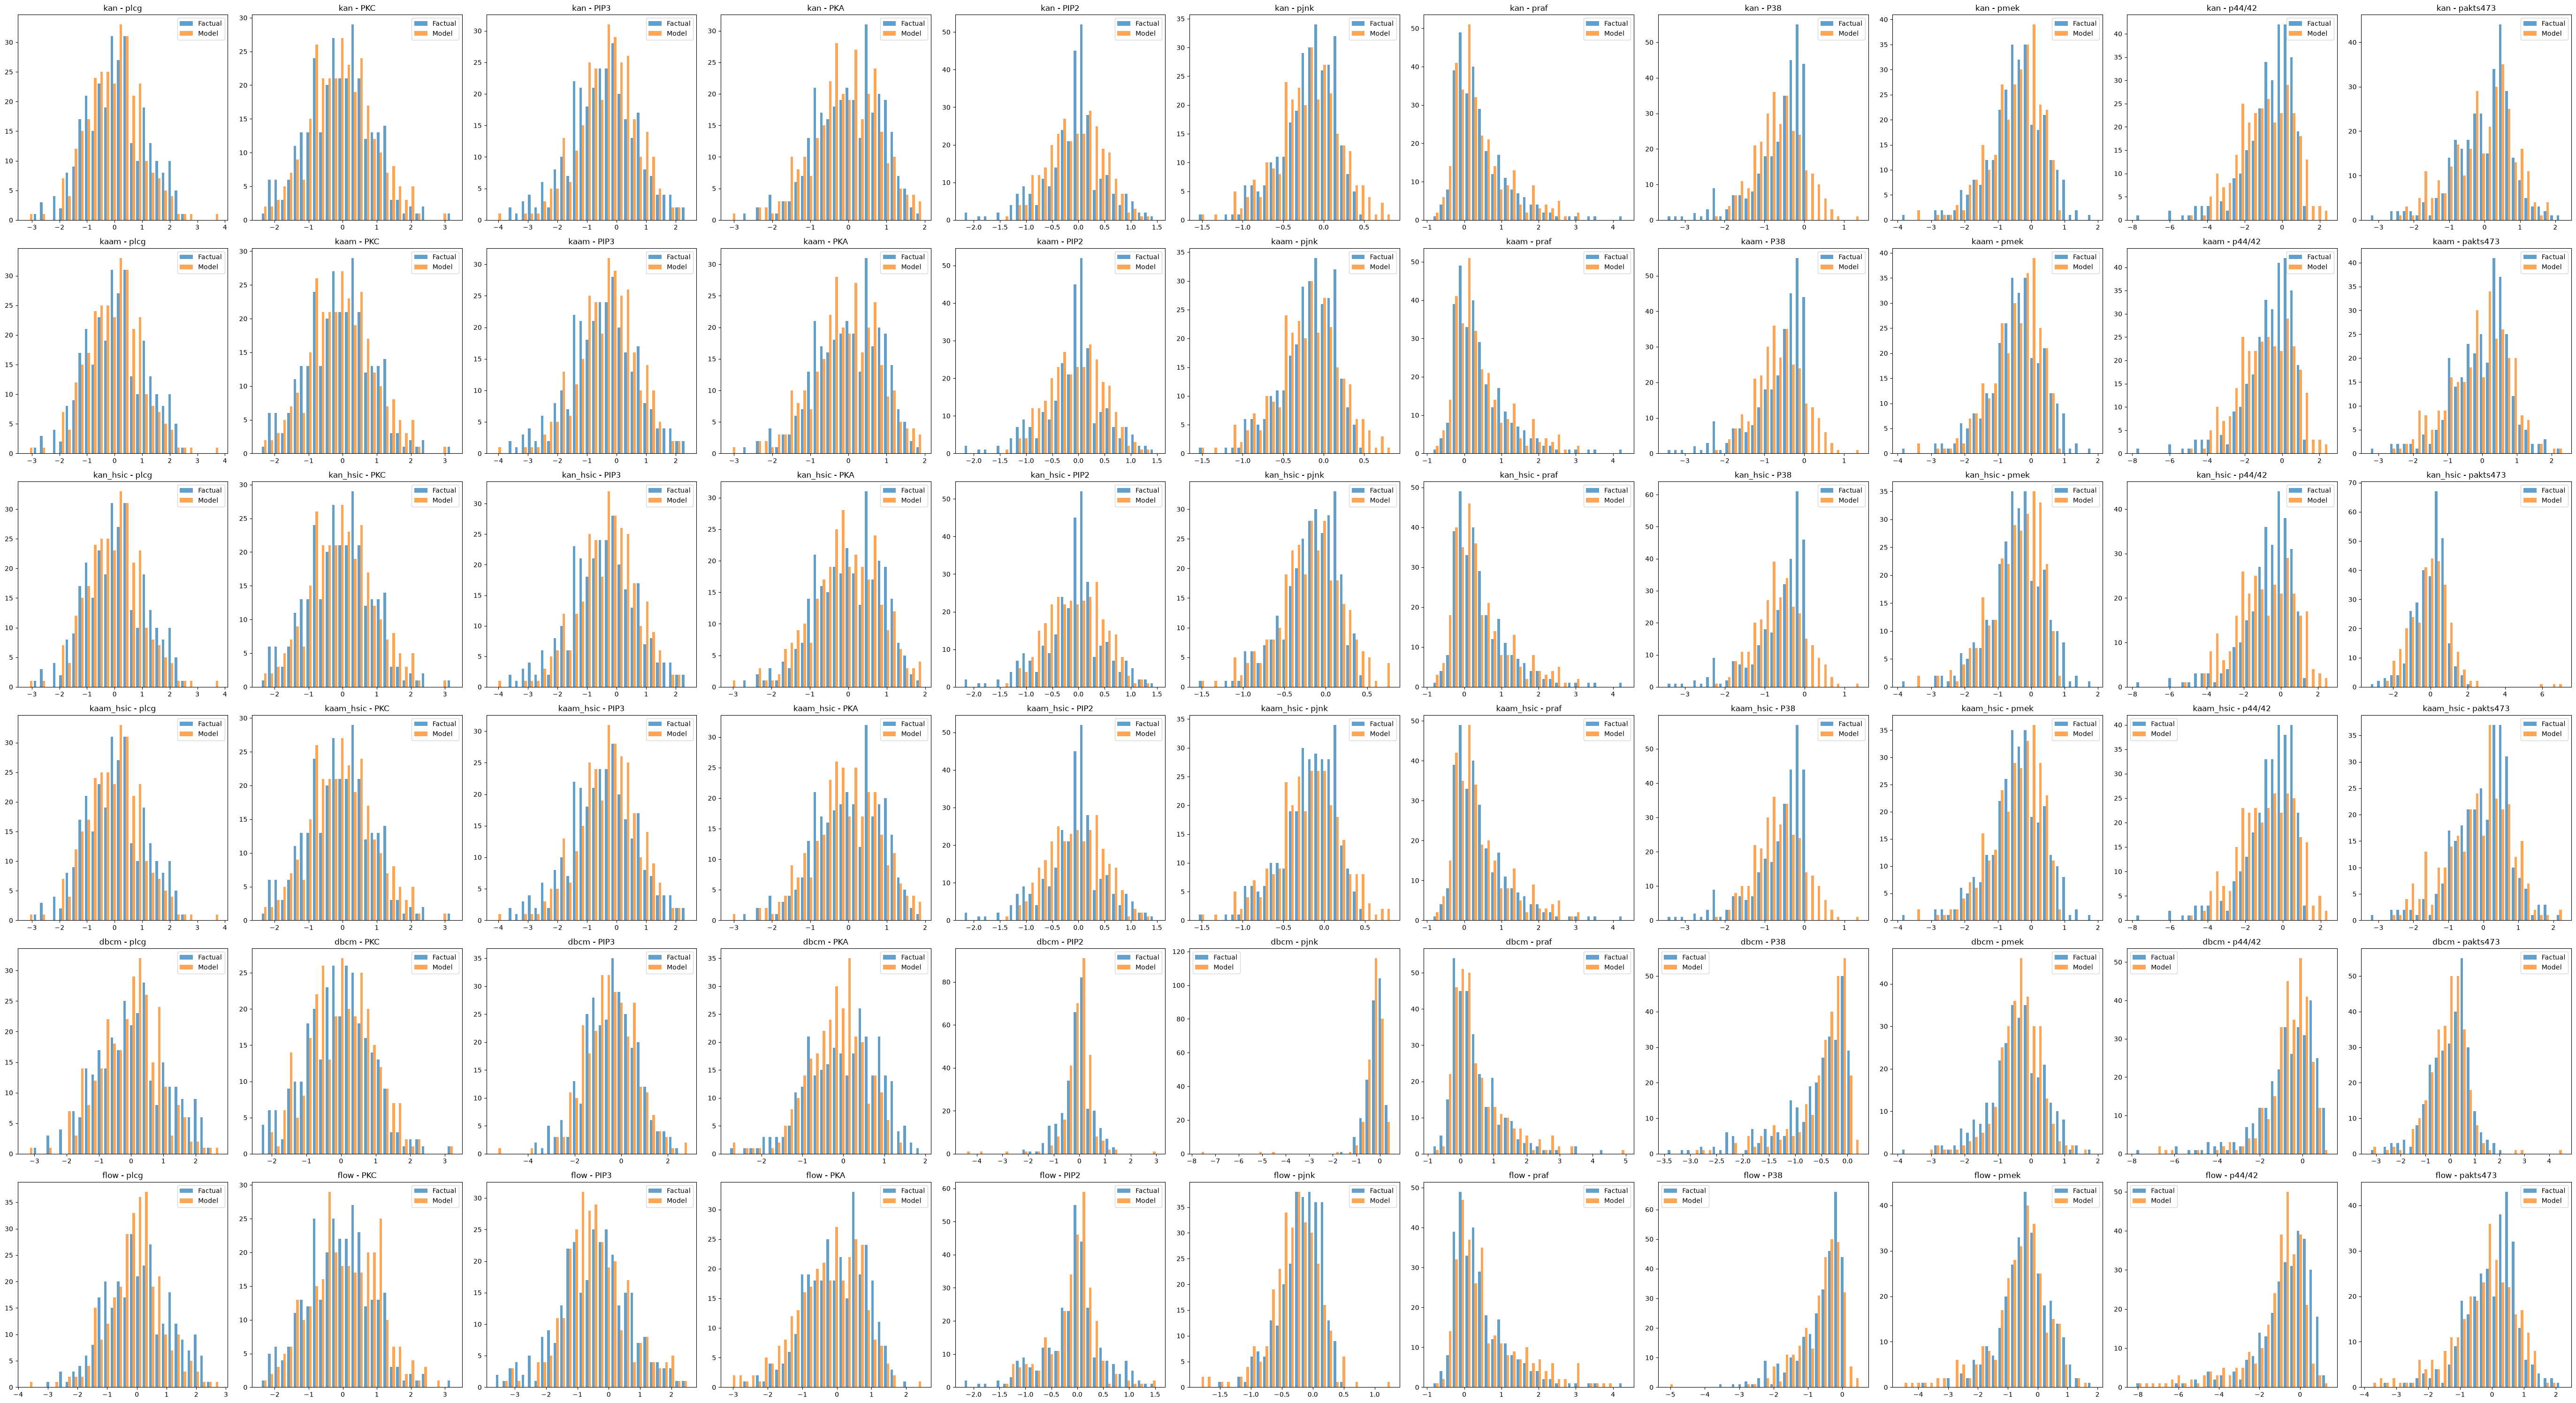

In [3]:
# Show the distributions of observational samples for all models compared to the factual data
nodes = factual_eval.columns
plt.subplots(len(model_names), len(nodes), figsize=(5 * len(nodes), 5 * len(model_names)))
for i, node in enumerate(nodes):
    for j, model_name in enumerate(model_names):
        obs_model = pd.read_csv(os.path.join(samples_dir, f"sachs_obs_samples_{model_name}.csv"))
        plt.subplot(len(model_names), len(nodes), j * len(nodes) + i + 1)
        plt.hist([factual_eval[node], obs_model[node]], bins=30, label=['Factual', 'Model'], alpha=0.7)
        plt.title(f'{model_name} - {node}')
        plt.legend(loc='best')
plt.tight_layout()
plt.show()



===== Formulas extraidas (kaam) =====
Extracted formula for node plcg using kaam model: N/A
Extracted formula for node PKC using kaam model: N/A
Extracted formula for node PIP3 using kaam model: -0.2447*plcg**2 + 0.6156*plcg - 0.1457
Extracted formula for node PKA using kaam model: -0.0491*PKC**2 - 0.4683*PKC - 0.1132
Extracted formula for node PIP2 using kaam model: -0.0203*PIP3**3 - 0.0515*PIP3**2 + 0.1352*PIP3 - 0.0278*plcg**3 - 0.0207*plcg**2 + 0.3565*plcg + 0.0019
Extracted formula for node pjnk using kaam model: 0.0228*PKA**4 + 0.0319*PKA**3 - 0.0882*PKA**2 + 0.2385*PKA + 0.0154*PKC**4 + 0.0038*PKC**3 - 0.1125*PKC**2 - 0.0014*PKC - 0.0927
Extracted formula for node praf using kaam model: -0.0222*PKA**4 - 0.0211*PKA**3 + 0.1999*PKA**2 + 0.0175*PKA + 0.2655*PKC**2 + 0.6183*PKC + 0.1108
Extracted formula for node P38 using kaam model: -0.1008*PKA**2 - 0.3204*PKA - 0.0871*PKC - 0.5235
Extracted formula for node pmek using kaam model: -0.3759*PKA**2 + 0.4277*PKA - 0.2427*PKC**2 + 0.2

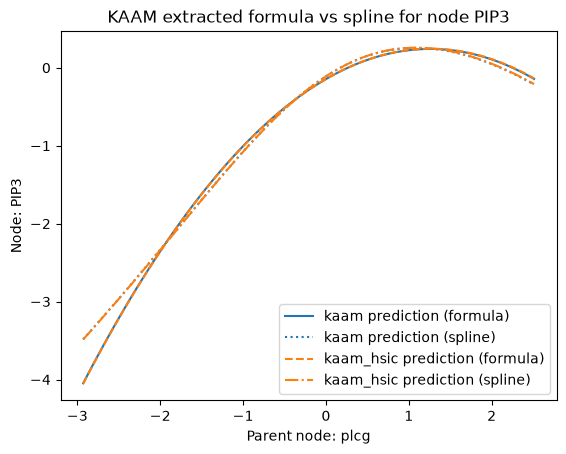

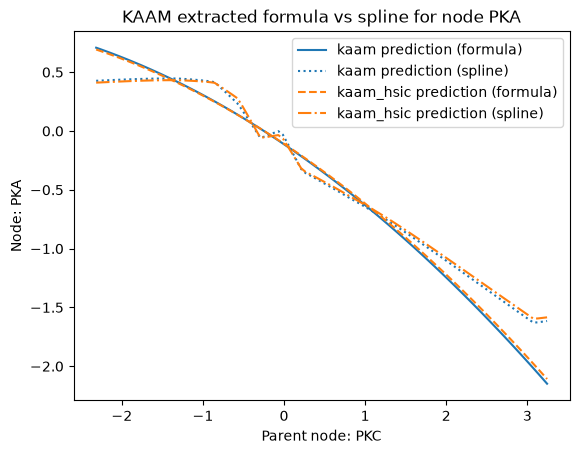

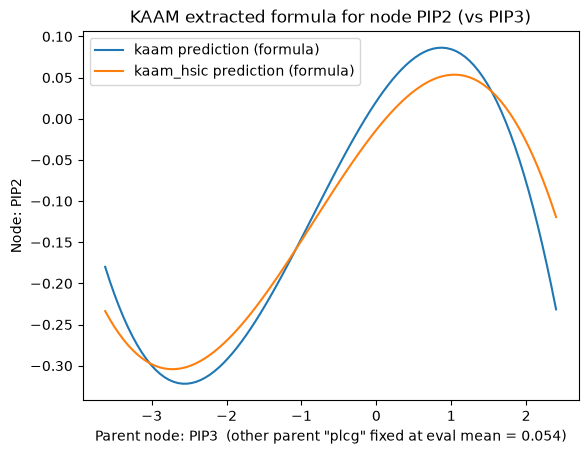

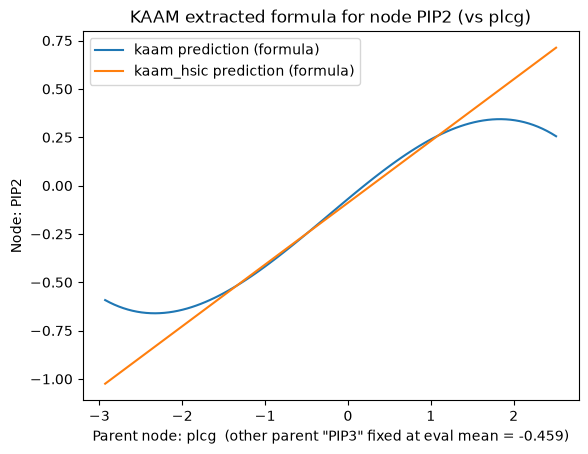

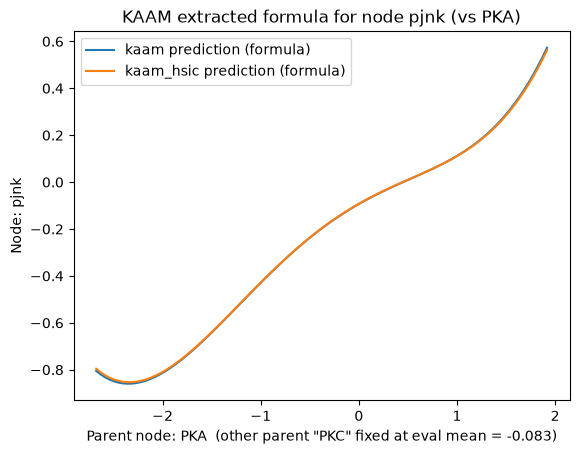

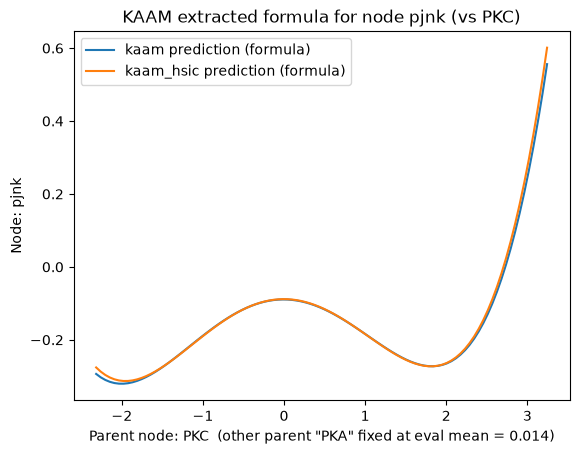

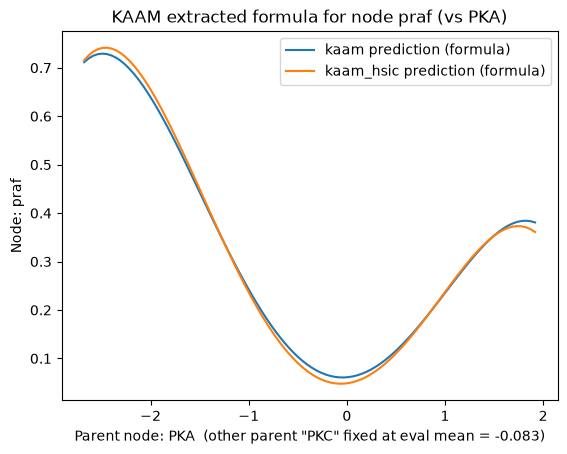

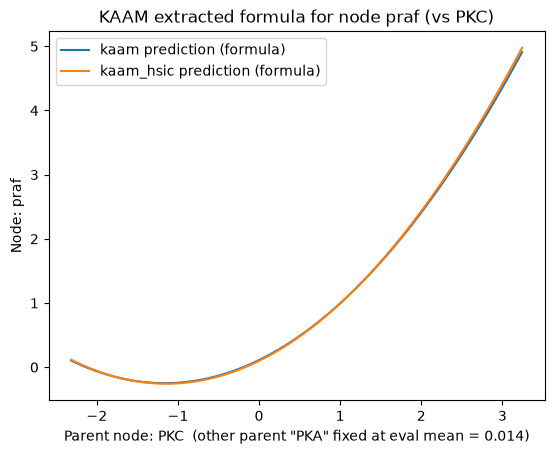

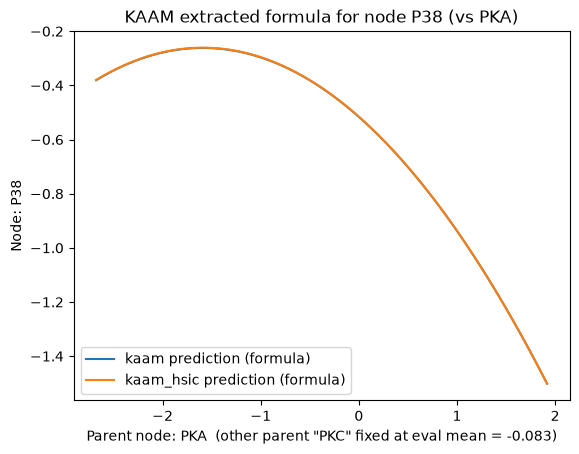

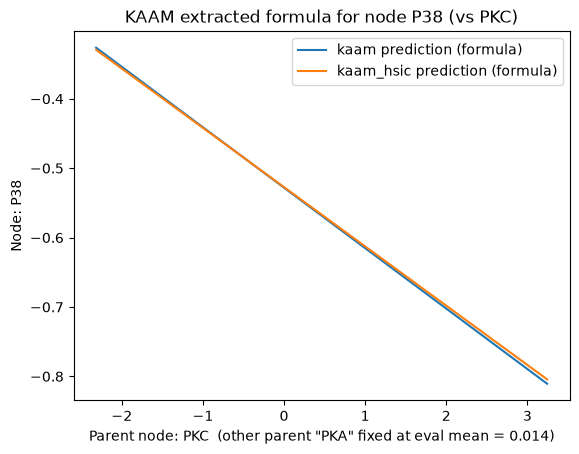

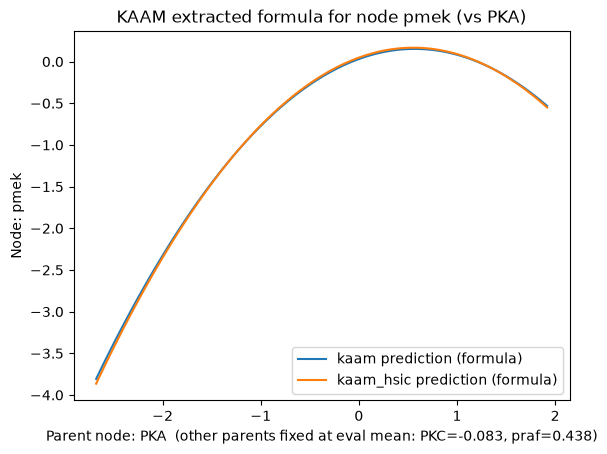

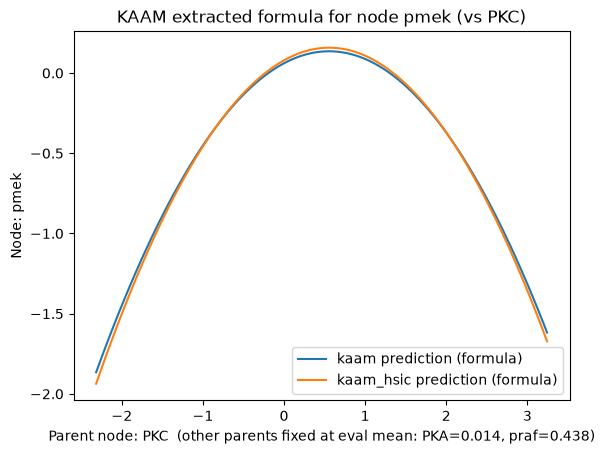

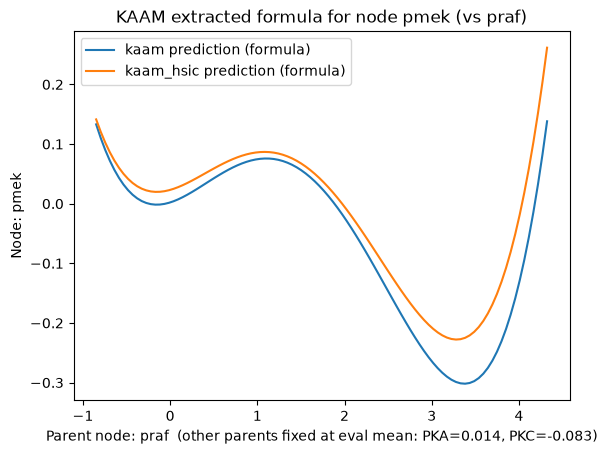

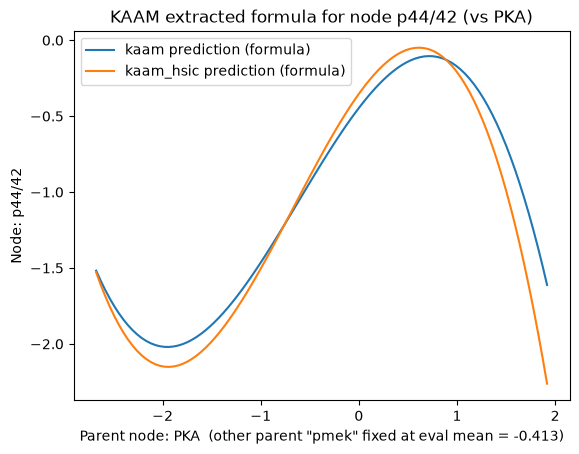

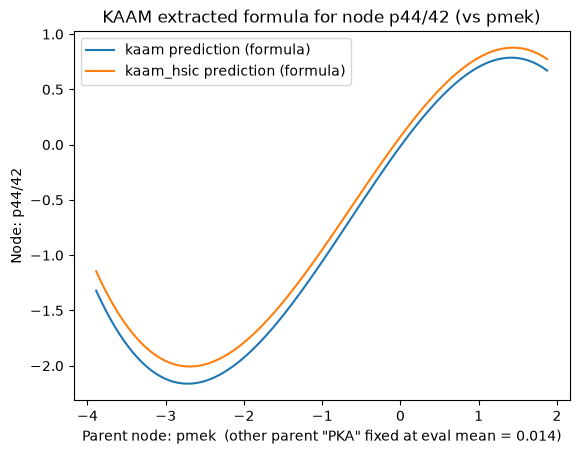

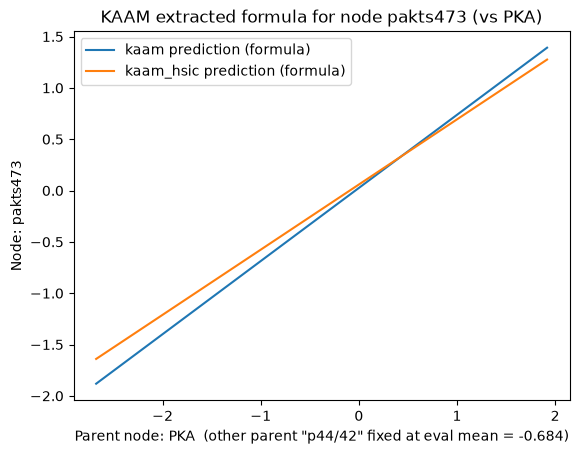

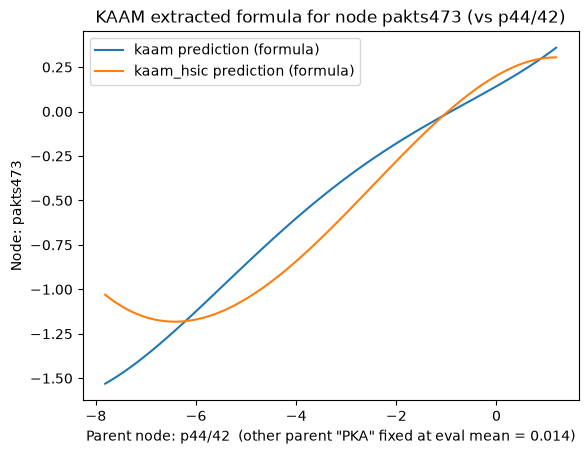

In [4]:
# Load the kaam / kaam_hsic results (extracted formulas, MAE, and per-node formula curves)
kaam_formula_results = {}
for kaam_variant in ['kaam', 'kaam_hsic']:
    with open(os.path.join(data_dir, f"sachs_results_{kaam_variant}.pkl"), 'rb') as f:
        kaam_formula_results[kaam_variant] = pickle.load(f)

for kaam_variant in ['kaam', 'kaam_hsic']:
    results = kaam_formula_results[kaam_variant]
    print(f"\n===== Formulas extraidas ({kaam_variant}) =====")
    for node in factual_eval.columns:
        print(f'Extracted formula for node {node} using {kaam_variant} model: {results.get(f"kaam_formula_{node}", "N/A")}')

    print(f'\nMAE results for {kaam_variant} formulas on SACHS dataset:')
    for node in factual_eval.columns:
        print(f'Node: {node}, MAE: {results.get(f"mae_{node}", "N/A")}')
    print(f'Global MAE: {results.get("mae", "N/A")}')


def formula_symbol(expr, name):
    """Look up a formula's Symbol by its exact name (avoids sympify() mis-parsing names
    that contain operator characters, e.g. the Sachs node 'p44/42' would otherwise be
    parsed as p44 / 42 if passed as a raw string to .subs())."""
    return next((s for s in expr.free_symbols if str(s) == name), None)


# Plot kaam vs kaam_hsic extracted formulas against each other (no ground-truth curve --
# structural_equations['nonadditive'] evaluated at noise=0 would NOT equal E[Y|parents] here,
# since noise is concatenated as an extra input before the nonlinear layer rather than added
# at the end; see notebook header for details. See sachs_hsic_beta_results.ipynb for the
# additive-noise version, which does overlay a true-function curve).
# - 1 parent: also overlay the raw KAN spline (kaam_pred_{node}), saved during training.
# - 2/3 parents: one plot per parent -- the raw spline predictions were only saved for
#   single-parent nodes in sachs_hsic_beta_nonadditive.ipynb -- with the other parent(s)
#   fixed at their population mean in factual_eval, i.e. all parent-to-child combinations.
# - >3 parents: not plotted -- too many combinations to show as 1D curves.
kaam_results = kaam_formula_results['kaam']
kaam_hsic_results = kaam_formula_results['kaam_hsic']
kaam_variants = [
    ('kaam', kaam_results, 'tab:blue'),
    ('kaam_hsic', kaam_hsic_results, 'tab:orange'),
]

for node in factual_eval.columns:
    n_parents = graph_sachs.in_degree(node)

    if n_parents == 1:
        parent_node = list(graph_sachs.predecessors(node))[0]
        x_vals_ref = kaam_results.get(f'x_vals_{node}', kaam_hsic_results.get(f'x_vals_{node}'))
        if x_vals_ref is None:
            continue
        if f'x_vals_{node}' in kaam_results:
            plt.plot(kaam_results[f'x_vals_{node}'], kaam_results[f'formula_pred_{node}'], label='kaam prediction (formula)', color='tab:blue', linestyle='-')
            plt.plot(kaam_results[f'x_vals_{node}'], kaam_results[f'kaam_pred_{node}'], label='kaam prediction (spline)', color='tab:blue', linestyle=':')
        if f'x_vals_{node}' in kaam_hsic_results:
            plt.plot(kaam_hsic_results[f'x_vals_{node}'], kaam_hsic_results[f'formula_pred_{node}'], label='kaam_hsic prediction (formula)', color='tab:orange', linestyle='--')
            plt.plot(kaam_hsic_results[f'x_vals_{node}'], kaam_hsic_results[f'kaam_pred_{node}'], label='kaam_hsic prediction (spline)', color='tab:orange', linestyle='-.')
        plt.xlabel(f'Parent node: {parent_node}')
        plt.ylabel(f'Node: {node}')
        plt.title(f'KAAM extracted formula vs spline for node {node}')
        plt.legend()
        plt.show()

    elif n_parents == 2:
        # sorted() to match get_ordered_predecessors (order the structural equation's parent
        # columns are built in) and x_names in sachs_hsic_beta.ipynb (order the formula symbols
        # were named in) -- both use sorted(predecessors), so this keeps everything aligned.
        parent_nodes = sorted(graph_sachs.predecessors(node))
        for i, parent_node in enumerate(parent_nodes):
            other_parent = parent_nodes[1 - i]
            other_mean = float(factual_eval[other_parent].mean())
            x_vals = np.linspace(factual_eval[parent_node].min(), factual_eval[parent_node].max(), 100)

            for kaam_variant, results, color in kaam_variants:
                formula = results.get(f'kaam_formula_{node}')
                if formula is None:
                    continue
                sym_other = formula_symbol(formula, other_parent)
                formula_fixed = formula.subs(sym_other, other_mean) if sym_other is not None else formula
                sym_parent = formula_symbol(formula_fixed, parent_node)
                if sym_parent is not None:
                    formula_vals = [float(formula_fixed.subs(sym_parent, x)) for x in x_vals]
                else:  # formula doesn't depend on this parent (e.g. pruned by r2_threshold)
                    formula_vals = [float(formula_fixed)] * len(x_vals)
                plt.plot(x_vals, formula_vals, label=f'{kaam_variant} prediction (formula)', color=color)

            plt.xlabel(f'Parent node: {parent_node}  (other parent "{other_parent}" fixed at eval mean = {other_mean:.3f})')
            plt.ylabel(f'Node: {node}')
            plt.title(f'KAAM extracted formula for node {node} (vs {parent_node})')
            plt.legend()
            plt.show()

    elif n_parents == 3:
        # Same strategy as the 2-parent case, generalized: for each parent, the other TWO
        # parents are fixed at their own population mean in factual_eval (only pmek has 3
        # parents: PKA, PKC, praf).
        parent_nodes = sorted(graph_sachs.predecessors(node))
        parent_means = {p: float(factual_eval[p].mean()) for p in parent_nodes}
        for i, parent_node in enumerate(parent_nodes):
            other_parents = [p for p in parent_nodes if p != parent_node]
            x_vals = np.linspace(factual_eval[parent_node].min(), factual_eval[parent_node].max(), 100)

            for kaam_variant, results, color in kaam_variants:
                formula = results.get(f'kaam_formula_{node}')
                if formula is None:
                    continue
                formula_fixed = formula
                for other_parent in other_parents:
                    sym_other = formula_symbol(formula_fixed, other_parent)
                    if sym_other is not None:
                        formula_fixed = formula_fixed.subs(sym_other, parent_means[other_parent])
                sym_parent = formula_symbol(formula_fixed, parent_node)
                if sym_parent is not None:
                    formula_vals = [float(formula_fixed.subs(sym_parent, x)) for x in x_vals]
                else:  # formula doesn't depend on this parent (e.g. pruned by r2_threshold)
                    formula_vals = [float(formula_fixed)] * len(x_vals)
                plt.plot(x_vals, formula_vals, label=f'{kaam_variant} prediction (formula)', color=color)

            other_desc = ', '.join(f'{p}={parent_means[p]:.3f}' for p in other_parents)
            plt.xlabel(f'Parent node: {parent_node}  (other parents fixed at eval mean: {other_desc})')
            plt.ylabel(f'Node: {node}')
            plt.title(f'KAAM extracted formula for node {node} (vs {parent_node})')
            plt.legend()
            plt.show()


Parents of pjnk: ['PKA', 'PKC']
Formula for pjnk (kaam): 0.0228*PKA**4 + 0.0319*PKA**3 - 0.0882*PKA**2 + 0.2385*PKA + 0.0154*PKC**4 + 0.0038*PKC**3 - 0.1125*PKC**2 - 0.0014*PKC - 0.0927
Formula for pjnk (kaam_hsic): 0.0227*PKA**4 + 0.0309*PKA**3 - 0.0889*PKA**2 + 0.2387*PKA + 0.0162*PKC**4 + 0.0031*PKC**3 - 0.1148*PKC**2 - 0.0003*PKC - 0.0918


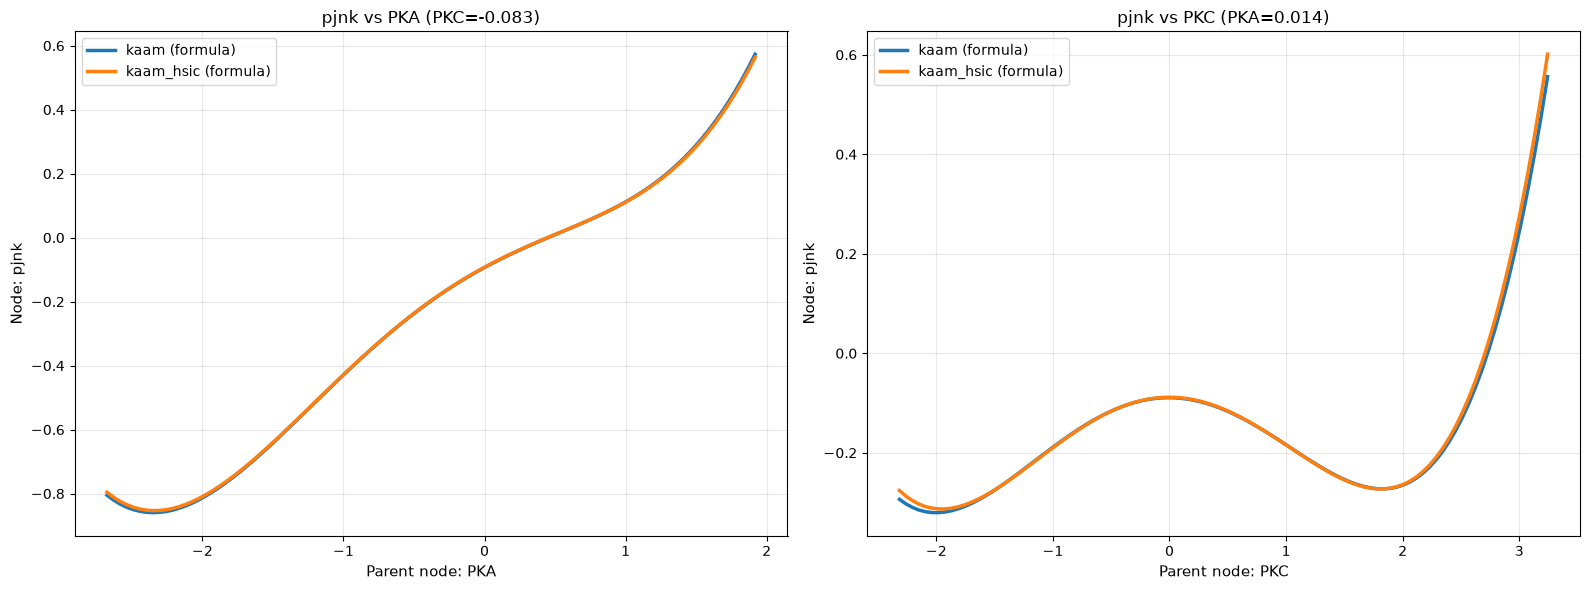

In [5]:
# Plot KAAM extracted formula for node pjnk vs PKA and vs PKC (with the other parent fixed at mean; no ground-truth curve, see cell above)
node = 'pjnk'
parent_nodes = sorted(graph_sachs.predecessors(node))
print(f"Parents of {node}: {parent_nodes}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: pjnk vs PKA (PKC fixed)
parent_node = 'PKA'
other_parent = 'PKC'
other_mean = float(factual_eval[other_parent].mean())
x_vals = np.linspace(factual_eval[parent_node].min(), factual_eval[parent_node].max(), 100)

for kaam_variant, results, color in kaam_variants:
    formula = results.get(f'kaam_formula_{node}')
    if formula is None:
        print(f'No formula for node {node} ({kaam_variant})')
        continue
    sym_other = formula_symbol(formula, other_parent)
    formula_fixed = formula.subs(sym_other, other_mean) if sym_other is not None else formula
    sym_parent = formula_symbol(formula_fixed, parent_node)
    if sym_parent is not None:
        formula_vals = [float(formula_fixed.subs(sym_parent, x)) for x in x_vals]
    else:
        formula_vals = [float(formula_fixed)] * len(x_vals)
    axes[0].plot(x_vals, formula_vals, label=f'{kaam_variant} (formula)', color=color, linewidth=2.5)
    if parent_node == 'PKA':
        print(f"Formula for {node} ({kaam_variant}): {formula}")

axes[0].set_xlabel(f'Parent node: {parent_node}', fontsize=11)
axes[0].set_ylabel(f'Node: {node}', fontsize=11)
axes[0].set_title(f'{node} vs {parent_node} ({other_parent}={other_mean:.3f})', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right plot: pjnk vs PKC (PKA fixed)
parent_node = 'PKC'
other_parent = 'PKA'
other_mean = float(factual_eval[other_parent].mean())
x_vals = np.linspace(factual_eval[parent_node].min(), factual_eval[parent_node].max(), 100)

for kaam_variant, results, color in kaam_variants:
    formula = results.get(f'kaam_formula_{node}')
    if formula is None:
        continue
    sym_other = formula_symbol(formula, other_parent)
    formula_fixed = formula.subs(sym_other, other_mean) if sym_other is not None else formula
    sym_parent = formula_symbol(formula_fixed, parent_node)
    if sym_parent is not None:
        formula_vals = [float(formula_fixed.subs(sym_parent, x)) for x in x_vals]
    else:
        formula_vals = [float(formula_fixed)] * len(x_vals)
    axes[1].plot(x_vals, formula_vals, label=f'{kaam_variant} (formula)', color=color, linewidth=2.5)

axes[1].set_xlabel(f'Parent node: {parent_node}', fontsize=11)
axes[1].set_ylabel(f'Node: {node}', fontsize=11)
axes[1].set_title(f'{node} vs {parent_node} ({other_parent}={other_mean:.3f})', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, f"sachs_kaam_formula_{node}_both_parents.pdf"), dpi=200, bbox_inches="tight")
plt.show()

 Parents of child node PIP3: {'plcg'}; we will compute interventions on plcg.
Full formula for Estimated Treatment Effect of node PIP3 using kaam model: -0.2447*plcg**2 + 0.6156*plcg - 0.1457
ATE formula estimated for child node PIP3 using kaam model when intervening on node plcg with values (-1.0, 1.0): 1.23120117187500
Full formula for Estimated Treatment Effect of node PIP3 using kaam_hsic model: -0.2445*plcg**2 + 0.6177*plcg - 0.1459
ATE formula estimated for child node PIP3 using kaam_hsic model when intervening on node plcg with values (-1.0, 1.0): 1.23539733886719


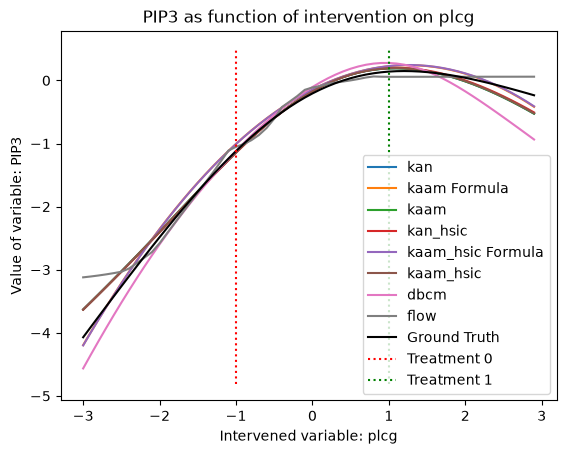

 Parents of child node PKA: {'PKC'}; we will compute interventions on PKC.
Full formula for Estimated Treatment Effect of node PKA using kaam model: -0.0491*PKC**2 - 0.4683*PKC - 0.1132
ATE formula estimated for child node PKA using kaam model when intervening on node PKC with values (-1.0, 1.0): -0.936599731445313
Full formula for Estimated Treatment Effect of node PKA using kaam_hsic model: -0.0486*PKC**2 - 0.4588*PKC - 0.1093
ATE formula estimated for child node PKA using kaam_hsic model when intervening on node PKC with values (-1.0, 1.0): -0.917602539062500


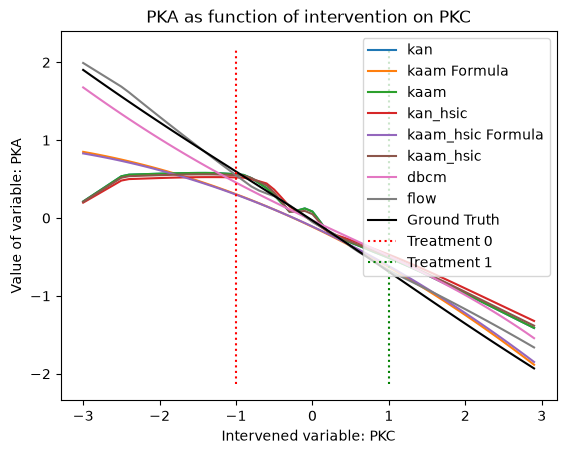

 Parents of child node PIP2: {'plcg', 'PIP3'}; we will compute interventions on plcg.
Full formula for Estimated Treatment Effect of node PIP2 using kaam model: -0.0203*PIP3**3 - 0.0515*PIP3**2 + 0.1352*PIP3 - 0.0278*plcg**3 - 0.0207*plcg**2 + 0.3565*plcg + 0.0019
ATE formula estimated for child node PIP2 using kaam model when intervening on node plcg with values (-1.0, 1.0): 0.657394409179688
Full formula for Estimated Treatment Effect of node PIP2 using kaam_hsic model: -0.0134*PIP3**3 - 0.0338*PIP3**2 + 0.1141*PIP3 + 0.3194*plcg - 0.0307
ATE formula estimated for child node PIP2 using kaam_hsic model when intervening on node plcg with values (-1.0, 1.0): 0.638801574707031


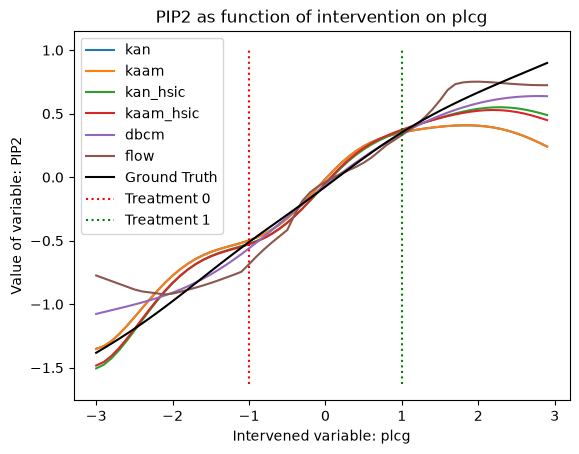

 Parents of child node pjnk: {'PKC', 'PKA'}; we will compute interventions on PKC.
Full formula for Estimated Treatment Effect of node pjnk using kaam model: 0.0228*PKA**4 + 0.0319*PKA**3 - 0.0882*PKA**2 + 0.2385*PKA + 0.0154*PKC**4 + 0.0038*PKC**3 - 0.1125*PKC**2 - 0.0014*PKC - 0.0927
ATE formula estimated for child node pjnk using kaam model when intervening on node PKC with values (-1.0, 1.0): 0.00479888916015625
Full formula for Estimated Treatment Effect of node pjnk using kaam_hsic model: 0.0227*PKA**4 + 0.0309*PKA**3 - 0.0889*PKA**2 + 0.2387*PKA + 0.0162*PKC**4 + 0.0031*PKC**3 - 0.1148*PKC**2 - 0.0003*PKC - 0.0918
ATE formula estimated for child node pjnk using kaam_hsic model when intervening on node PKC with values (-1.0, 1.0): 0.00559997558593750


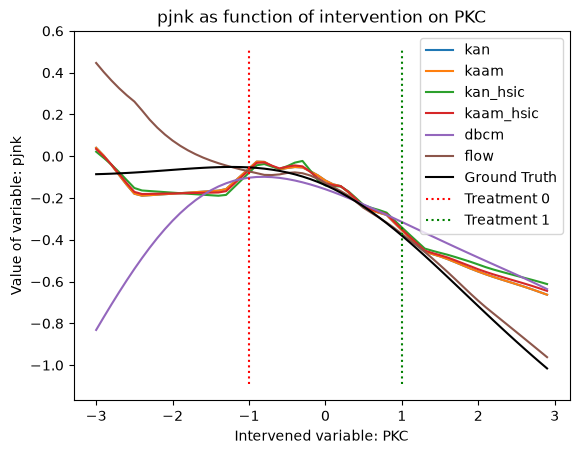

 Parents of child node praf: {'PKC', 'PKA'}; we will compute interventions on PKC.
Full formula for Estimated Treatment Effect of node praf using kaam model: -0.0222*PKA**4 - 0.0211*PKA**3 + 0.1999*PKA**2 + 0.0175*PKA + 0.2655*PKC**2 + 0.6183*PKC + 0.1108
ATE formula estimated for child node praf using kaam model when intervening on node PKC with values (-1.0, 1.0): 1.23660278320313
Full formula for Estimated Treatment Effect of node praf using kaam_hsic model: -0.0251*PKA**4 - 0.0259*PKA**3 + 0.2133*PKA**2 + 0.0261*PKA + 0.2719*PKC**2 + 0.6225*PKC + 0.0986
ATE formula estimated for child node praf using kaam_hsic model when intervening on node PKC with values (-1.0, 1.0): 1.24499511718750


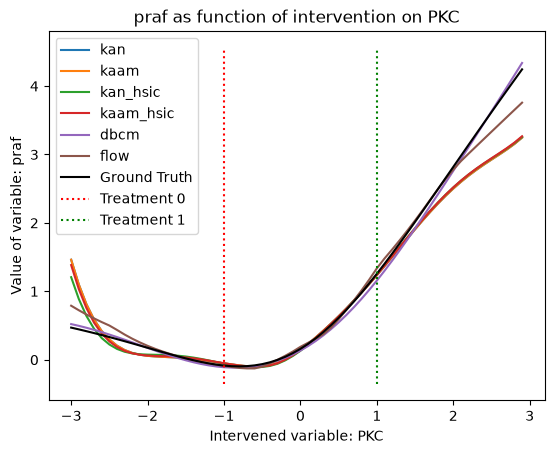

 Parents of child node P38: {'PKC', 'PKA'}; we will compute interventions on PKC.
Full formula for Estimated Treatment Effect of node P38 using kaam model: -0.1008*PKA**2 - 0.3204*PKA - 0.0871*PKC - 0.5235
ATE formula estimated for child node P38 using kaam model when intervening on node PKC with values (-1.0, 1.0): -0.174194335937500
Full formula for Estimated Treatment Effect of node P38 using kaam_hsic model: -0.1009*PKA**2 - 0.3207*PKA - 0.0854*PKC - 0.5227
ATE formula estimated for child node P38 using kaam_hsic model when intervening on node PKC with values (-1.0, 1.0): -0.170806884765625


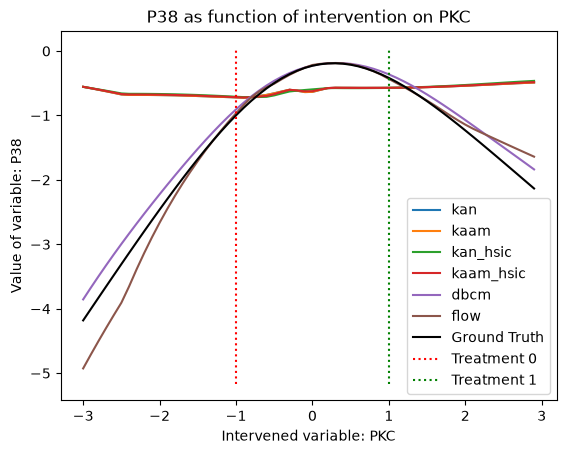

 Parents of child node pmek: {'PKC', 'praf', 'PKA'}; we will compute interventions on PKC.
Full formula for Estimated Treatment Effect of node pmek using kaam model: -0.3759*PKA**2 + 0.4277*PKA - 0.2427*PKC**2 + 0.2695*PKC + 0.0202*praf**4 - 0.1165*praf**3 + 0.1228*praf**2 + 0.046*praf + 0.0202
ATE formula estimated for child node pmek using kaam model when intervening on node PKC with values (-1.0, 1.0): 0.539001464843750
Full formula for Estimated Treatment Effect of node pmek using kaam_hsic model: -0.386*PKA**2 + 0.4287*PKA - 0.2537*PKC**2 + 0.2827*PKC + 0.0189*praf**4 - 0.1062*praf**3 + 0.1091*praf**2 + 0.0412*praf + 0.0424
ATE formula estimated for child node pmek using kaam_hsic model when intervening on node PKC with values (-1.0, 1.0): 0.565399169921875


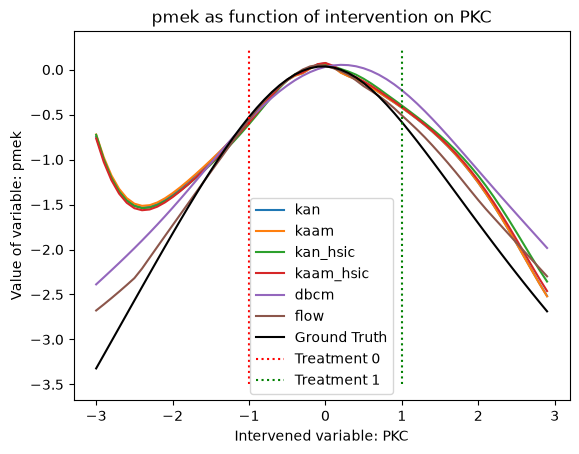

 Parents of child node p44/42: {'PKC', 'praf', 'pmek', 'PKA'}; we will compute interventions on PKC.
Full formula for Estimated Treatment Effect of node p44/42 using kaam model: -0.2015*PKA**3 - 0.3722*PKA**2 + 0.8474*PKA - 0.0834*pmek**3 - 0.1629*pmek**2 + 0.9637*pmek - 0.0265
ATE formula estimated for child node p44/42 using kaam model when intervening on node PKC with values (-1.0, 1.0): 0
Full formula for Estimated Treatment Effect of node p44/42 using kaam_hsic model: -0.2526*PKA**3 - 0.5038*PKA**2 + 0.9001*PKA - 0.0817*pmek**3 - 0.1539*pmek**2 + 0.9501*pmek + 0.0595
ATE formula estimated for child node p44/42 using kaam_hsic model when intervening on node PKC with values (-1.0, 1.0): 0


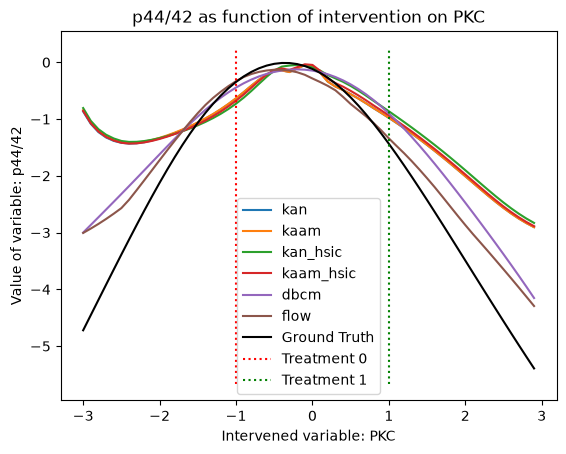

 Parents of child node pakts473: {'PKC', 'p44/42', 'pmek', 'PKA', 'praf'}; we will compute interventions on PKC.
Full formula for Estimated Treatment Effect of node pakts473 using kaam model: 0.7124*PKA + 0.0005*p44/42**4 + 0.0061*p44/42**3 + 0.0101*p44/42**2 + 0.1606*p44/42 + 0.1321
ATE formula estimated for child node pakts473 using kaam model when intervening on node PKC with values (-1.0, 1.0): 0
Full formula for Estimated Treatment Effect of node pakts473 using kaam_hsic model: 0.6347*PKA - 0.0001*p44/42**4 - 0.0078*p44/42**3 - 0.0542*p44/42**2 + 0.1624*p44/42 + 0.1924
ATE formula estimated for child node pakts473 using kaam_hsic model when intervening on node PKC with values (-1.0, 1.0): 0


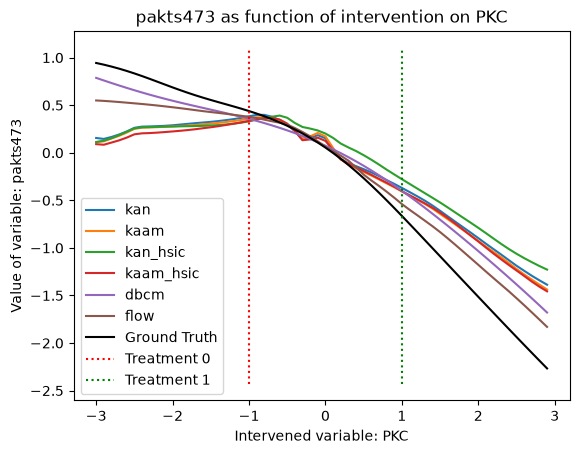

╒═══════════════╤══════════════╤═══════════════════╤════════════════════╤═════════════╤═════════════╤═════════════════╕
│ Parent node   │ Child node   │ Model             │   ATE Ground Truth │   ATE Model │   Abs Error │   Rel Error (%) │
╞═══════════════╪══════════════╪═══════════════════╪════════════════════╪═════════════╪═════════════╪═════════════════╡
│ plcg          │ PIP3         │ kan               │             1.2600 │      1.3294 │      0.0694 │          5.5054 │
├───────────────┼──────────────┼───────────────────┼────────────────────┼─────────────┼─────────────┼─────────────────┤
│ plcg          │ PIP3         │ kaam              │             1.2600 │      1.3294 │      0.0694 │          5.5058 │
├───────────────┼──────────────┼───────────────────┼────────────────────┼─────────────┼─────────────┼─────────────────┤
│ plcg          │ PIP3         │ kaam formula      │             1.2600 │      1.2312 │      0.0288 │          2.2885 │
├───────────────┼──────────────┼────────

In [6]:
# ATE example on a single variable: formula vs ground truth vs each model
intervention_values = (-1.0, 1.0)

ate_table = []

for child_node in factual_eval.columns:
    n_parents = graph_sachs.in_degree(child_node)
    if n_parents > 0:  # Only when there exists at least a parent!
        parent_nodes = nx.ancestors(graph_sachs, child_node)
        parent_node = f'{list(parent_nodes)[0]}'  # We will only plot results intervening on the first parent
        print(f' Parents of child node {child_node}: {parent_nodes}; we will compute interventions on {parent_node}.')
        parent_cf_values = {parent_node: {'cf_gt_0': None, 'cf_gt_1': None, 'gt_ate': None}}
        for node_, value_, d_ in inter_vector:
            if parent_node == node_:
                if np.abs(value_ - intervention_values[0]) < 1e-3:
                    parent_cf_values[parent_node]['cf_gt_0'] = d_[child_node]
                if np.abs(value_ - intervention_values[1]) < 1e-3:
                    parent_cf_values[parent_node]['cf_gt_1'] = d_[child_node]
        parent_cf_values[parent_node]['gt_ate'] = np.mean(parent_cf_values[parent_node]['cf_gt_1'].to_numpy()) - np.mean(parent_cf_values[parent_node]['cf_gt_0'].to_numpy())

        for model_name in model_names:
            with open(os.path.join(data_dir, f'sachs_cf_eval_{model_name}.pkl'), 'rb') as f:
                results_cf = pickle.load(f)
            for node_, value_, d_ in results_cf:
                if parent_node == node_:
                    if np.abs(value_ - intervention_values[0]) < 1e-3:
                        parent_cf_values[parent_node][f'cf_{model_name}_0'] = d_[child_node]
                    if np.abs(value_ - intervention_values[1]) < 1e-3:
                        parent_cf_values[parent_node][f'cf_{model_name}_1'] = d_[child_node]
            parent_cf_values[parent_node][f'{model_name}_ate'] = np.mean(parent_cf_values[parent_node][f'cf_{model_name}_1'].to_numpy()) - np.mean(parent_cf_values[parent_node][f'cf_{model_name}_0'].to_numpy())
            abs_ate_error = np.abs(parent_cf_values[parent_node]['gt_ate'] - parent_cf_values[parent_node][f'{model_name}_ate'])
            rel_ate_erro = 100 * abs_ate_error / np.abs(parent_cf_values[parent_node]['gt_ate'])
            ate_table.append([parent_node, child_node, model_name, parent_cf_values[parent_node]['gt_ate'], parent_cf_values[parent_node][f'{model_name}_ate'], abs_ate_error, rel_ate_erro])

            if model_name in ('kaam', 'kaam_hsic'):
                # Now, create a symbolic function using the formulas extracted by kaam / kaam_hsic
                child_node_formula = kaam_formula_results[model_name].get(f'kaam_formula_{child_node}', None)
                if child_node_formula is None:
                    print(f'No formula for node {child_node} in {model_name} model')
                else:
                    kaam_ate_formula = child_node_formula.subs(parent_node, intervention_values[1]) - child_node_formula.subs(parent_node, intervention_values[0])
                    print(f'Full formula for Estimated Treatment Effect of node {child_node} using {model_name} model: {child_node_formula}')
                    print(f'ATE formula estimated for child node {child_node} using {model_name} model when intervening on node {parent_node} with values {intervention_values}: {kaam_ate_formula}')
                    ate_formula_val = float(kaam_ate_formula)
                    abs_ate_error_f = np.abs(parent_cf_values[parent_node]['gt_ate'] - ate_formula_val)
                    rel_ate_erro_f = 100 * abs_ate_error_f / np.abs(parent_cf_values[parent_node]['gt_ate'])
                    ate_table.append([parent_node, child_node, f'{model_name} formula', parent_cf_values[parent_node]['gt_ate'], ate_formula_val, abs_ate_error_f, rel_ate_erro_f])

                    if n_parents == 1:  # We can only plot this for single-parent nodes
                        kaam_cf_vals = [float(child_node_formula.subs(parent_node, x)) for x in list(cf_vector_values)]
                        plt.plot(cf_vector_values, kaam_cf_vals, label=f'{model_name} Formula')

            # Plot the expected effect curve for this model
            cf_vals_ordered = []
            for value_o in list(cf_vector_values):
                for node_, value_, d_ in results_cf:
                    if parent_node == node_ and np.abs(value_ - value_o) < 1e-3:
                        cf_vals_ordered.append(np.mean(d_[child_node].to_numpy()))
            plt.plot(cf_vector_values, cf_vals_ordered, label=model_name)

        # Now, let's obtain the ATE plot using the structural equations (ground truth)
        if child_node in structural_equations['nonadditive']:
            cf_gt_vals = []
            for value_o in list(cf_vector_values):
                for node_, value_, d_ in inter_vector:
                    if parent_node == node_ and np.abs(value_ - value_o) < 1e-3:
                        cf_gt_vals.append(np.mean(d_[child_node].to_numpy()))
            cf_gt_vals = np.array(cf_gt_vals)
            plt.plot(cf_vector_values, cf_gt_vals, label='Ground Truth', color='black')
            y_min, y_max = plt.ylim()
            plt.vlines(intervention_values[0], ymin=y_min, ymax=y_max, color='red', linestyle=':', label='Treatment 0')
            plt.vlines(intervention_values[1], ymin=y_min, ymax=y_max, color='green', linestyle=':', label='Treatment 1')
            plt.xlabel(f'Intervened variable: {parent_node}')
            plt.ylabel(f'Value of variable: {child_node}')
            plt.title(f'{child_node} as function of intervention on {parent_node}')
            plt.legend()
            plt.show()

print(tabulate(ate_table,
               headers=['Parent node', 'Child node', 'Model', 'ATE Ground Truth', 'ATE Model', 'Abs Error', 'Rel Error (%)'],
               floatfmt=".4f", tablefmt="fancy_grid"))

# Create an average ATE table, for each model compute the avg and std of the ATE error
ate_table_avg = []
for row_model in model_names + ['kaam formula', 'kaam_hsic formula']:
    values_to_avg = [row[5:] for row in ate_table if row[2] == row_model]
    if not values_to_avg:
        continue
    values_to_avg = np.array(values_to_avg)
    mean = np.mean(values_to_avg, axis=0)
    std = np.std(values_to_avg, axis=0)
    ate_table_avg.append([row_model] + [f'{mean[i]:.2f} ({std[i]:.2f})' for i in range(len(mean))])

print(tabulate(ate_table_avg, headers=['Model name', 'Abs error', 'Rel error (%)'], floatfmt=".4f", tablefmt="fancy_grid"))


Parents of pjnk: ['PKA', 'PKC']


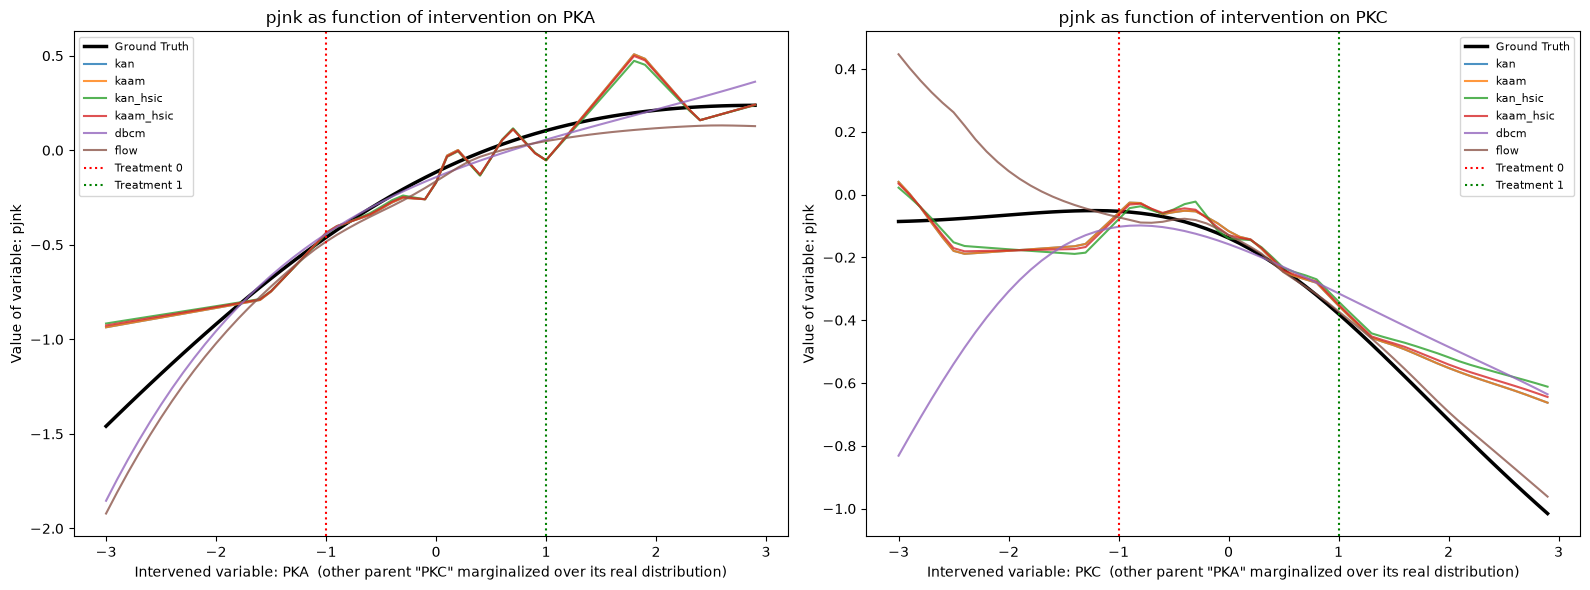

In [7]:
# Replot the ATE-style dose-response curves explicitly for BOTH parents of pjnk (PKA and PKC).
# The generic loop above only intervenes on list(parent_nodes)[0] (an arbitrary pick from a
# set), so for a 2-parent node like pjnk it only ever shows one of the two relationships.
# This cell repeats the same sampled-model / ground-truth logic for child_node='pjnk', once
# per parent (sampled curves only -- no kaam/kaam_hsic formula overlay).
child_node = 'pjnk'
parent_nodes_pjnk = sorted(graph_sachs.predecessors(child_node))
print(f'Parents of {child_node}: {parent_nodes_pjnk}')

fig, axes = plt.subplots(1, len(parent_nodes_pjnk), figsize=(8 * len(parent_nodes_pjnk), 6))

for ax, parent_node in zip(axes, parent_nodes_pjnk):
    other_parent = [p for p in parent_nodes_pjnk if p != parent_node][0]

    # Ground truth: sampled counterfactuals from the true generator (precomputed in inter_vector)
    cf_gt_vals = []
    for value_o in list(cf_vector_values):
        for node_, value_, d_ in inter_vector:
            if parent_node == node_ and np.abs(value_ - value_o) < 1e-3:
                cf_gt_vals.append(np.mean(d_[child_node].to_numpy()))
    ax.plot(cf_vector_values, cf_gt_vals, label='Ground Truth', color='black', linewidth=2.5)

    # Each fitted model's sampled dose-response curve
    for model_name in model_names:
        with open(os.path.join(data_dir, f'sachs_cf_eval_{model_name}.pkl'), 'rb') as f:
            results_cf = pickle.load(f)
        cf_vals_ordered = []
        for value_o in list(cf_vector_values):
            for node_, value_, d_ in results_cf:
                if parent_node == node_ and np.abs(value_ - value_o) < 1e-3:
                    cf_vals_ordered.append(np.mean(d_[child_node].to_numpy()))
        ax.plot(cf_vector_values, cf_vals_ordered, label=model_name, alpha=0.8)

    y_min, y_max = ax.get_ylim()
    ax.vlines(intervention_values[0], ymin=y_min, ymax=y_max, color='red', linestyle=':', label='Treatment 0')
    ax.vlines(intervention_values[1], ymin=y_min, ymax=y_max, color='green', linestyle=':', label='Treatment 1')
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel(f'Intervened variable: {parent_node}  (other parent "{other_parent}" marginalized over its real distribution)')
    ax.set_ylabel(f'Value of variable: {child_node}')
    ax.set_title(f'{child_node} as function of intervention on {parent_node}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, f"sachs_ate_{child_node}_both_parents.pdf"), dpi=200, bbox_inches="tight")
plt.show()


| model                  | rf_acc_obs       | mmd_obs          |
|------------------------|------------------|------------------|
| KAN (mse)              | 0.6913 +- 0.0468 | 0.0107 +- 0.0035 |
| KAN $\beta$=0.3 (opt)  | 0.6954 +- 0.0401 | 0.0113 +- 0.0038 |
| KAAM (mse)             | 0.6913 +- 0.0397 | 0.0108 +- 0.0036 |
| KAAM $\beta$=0.1 (opt) | 0.6913 +- 0.0523 | 0.0109 +- 0.0037 |
| DBCM                   | 0.6238 +- 0.0474 | 0.0083 +- 0.0040 |
| Causal flow            | 0.6446 +- 0.0340 | 0.0082 +- 0.0024 |


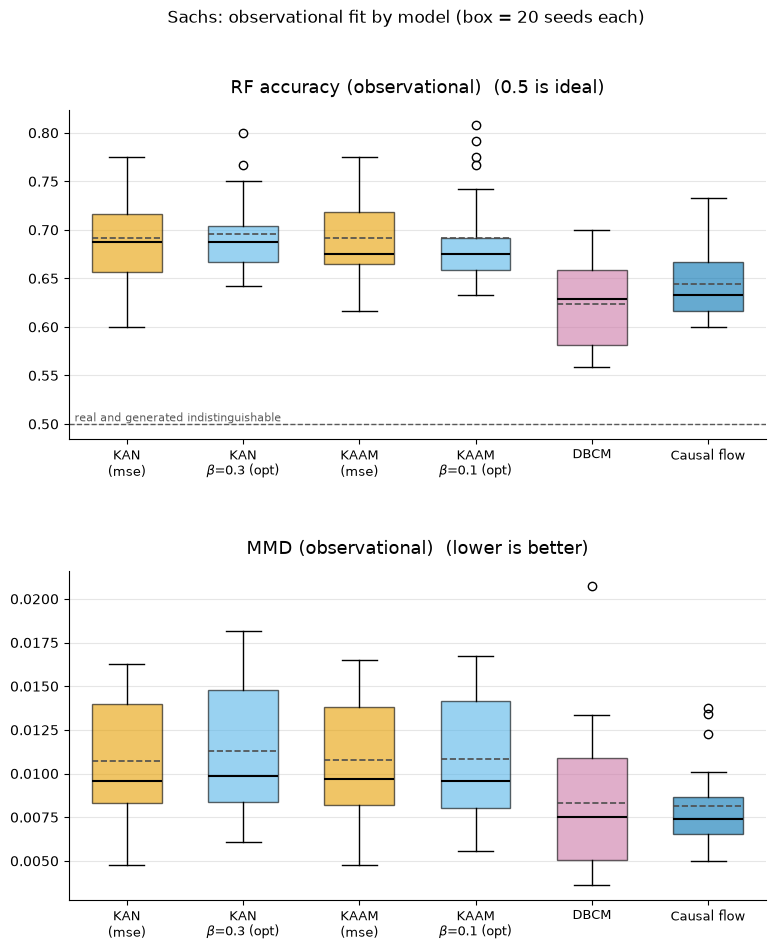


Figure written to C:\Users\aarna\Desktop\clau\TFM Claudia\kacgm-hsic\outputs\sachs_hsic_nonadditive\figures


In [8]:
# ============================================================== Metric comparison box plot
# Box = distribution over the 20 beta-sweep seeds (beta_sweep_seeds, sachs_hsic_beta.ipynb).
# Restricted to RF accuracy and MMD (observational).
#
# kan/kaam use the beta=0 (pure mse) slice of the sweep; kan_hsic/kaam_hsic use the
# beta_opt slice -- i.e. exactly the beta that minimises mean rf_acc_obs over these same 20
# seeds, so this box IS the distribution the optimum was chosen from, not a separate run.
#
# dbcm/flow now also have a real 20-seed box: sachs_hsic_beta.ipynb's standalone "Barrido de
# 20 semillas para dbcm y flow" cell trained them on the same 20 per-seed training sets used
# by the kan/kaam sweep, saved to sachs_dbcm_sweep_por_semilla.pkl / sachs_flow_sweep_por_semilla.pkl
# (same {seed: {mmd_obs, rf_acc_obs, training_time}} shape as beta0_sweep_results_por_semilla).

with open(os.path.join(data_dir, "sachs_dbcm_sweep_por_semilla.pkl"), 'rb') as f:
    dbcm_sweep_por_semilla = pickle.load(f)
with open(os.path.join(data_dir, "sachs_flow_sweep_por_semilla.pkl"), 'rb') as f:
    flow_sweep_por_semilla = pickle.load(f)


def seed_values(per_seed_dict, metric):
    return [v[metric] for v in per_seed_dict.values()]


# (per-seed results dict, display label, colour), in the order the boxes are drawn.
BOX_MODELS = [
    (beta0_sweep_results_por_semilla['kan'],                    'KAN\n(mse)',                                 '#E69F00'),
    (beta_sweep_results_por_semilla['kan'][beta_opt['kan']],    f"KAN\n$\\beta$={beta_opt['kan']:g} (opt)",   '#56B4E9'),
    (beta0_sweep_results_por_semilla['kaam'],                   'KAAM\n(mse)',                                '#E69F00'),
    (beta_sweep_results_por_semilla['kaam'][beta_opt['kaam']],  f"KAAM\n$\\beta$={beta_opt['kaam']:g} (opt)", '#56B4E9'),
    (dbcm_sweep_por_semilla,                                    'DBCM',                                       '#CC79A7'),
    (flow_sweep_por_semilla,                                    'Causal flow',                                '#0072B2'),
]

BOX_METRICS = [
    ('rf_acc_obs', 'RF accuracy (observational)', '0.5 is ideal'),
    ('mmd_obs',    'MMD (observational)',          'lower is better'),
]

all_labels = [label for _, label, _ in BOX_MODELS]
positions = np.arange(1, len(all_labels) + 1)

# Summary table: mean +- std over the n seeds behind each box.
summary_rows = []
for per_seed, label, _ in BOX_MODELS:
    rf_vals, mmd_vals = seed_values(per_seed, 'rf_acc_obs'), seed_values(per_seed, 'mmd_obs')
    summary_rows.append([label.replace('\n', ' '), f'{np.mean(rf_vals):.4f} +- {np.std(rf_vals):.4f}',
                          f'{np.mean(mmd_vals):.4f} +- {np.std(mmd_vals):.4f}'])
print(tabulate(summary_rows, headers=['model', 'rf_acc_obs', 'mmd_obs'], tablefmt='github'))

fig, axs = plt.subplots(len(BOX_METRICS), 1, figsize=(9, 10), sharex=False)

for ax, (metric, title, direction) in zip(axs, BOX_METRICS):
    box_data = [seed_values(per_seed, metric) for per_seed, _, _ in BOX_MODELS]
    bplot = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                        showmeans=True, meanline=True,
                        medianprops=dict(color='black', linewidth=1.5),
                        meanprops=dict(color='0.3', linewidth=1.2, linestyle='--'))
    for patch, (_, _, color) in zip(bplot['boxes'], BOX_MODELS):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    if metric == 'rf_acc_obs':
        ax.axhline(0.5, color='0.35', ls='--', lw=1)
        ax.text(positions[0] - 0.45, 0.5, 'real and generated indistinguishable', va='bottom', ha='left',
                fontsize=8, color='0.35')

    ax.set_title(f'{title}  ({direction})', fontsize=13, loc='center', pad=12)
    ax.grid(axis='y', color='0.9', lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xticks(positions)
    ax.set_xticklabels(all_labels, fontsize=9)

fig.suptitle(f'Sachs: observational fit by model (box = {len(beta_sweep_seeds)} seeds each)', fontsize=12, y=1.0)
fig.subplots_adjust(top=0.9, hspace=0.4)

fig.savefig(os.path.join(figures_dir, 'sachs_metrics_boxplot.pdf'), bbox_inches='tight')
plt.show()

print(f'\nFigure written to {figures_dir}')


In [9]:
# Interventional and counterfactual metrics per model, as mean +- std across the 660
# (node, value) intervention scenarios (11 nodes x 60 values in cf_vector_values, see
# "Generate the SACHS dataset" cell / inter_vector). Unlike the "Load and print the results"
# table above (which only shows the *_avg mean), this uses the *_all lists saved alongside
# each *_avg in sachs_results_{model}.pkl -- one raw mmd_int/rf_acc_int/mse_cf/mae_cf value per
# scenario -- to also report the spread across scenarios, not just its mean.
int_cf_metrics = ['rf_acc_int', 'mmd_int', 'mae_cf']

int_cf_table = []
for model_name in model_names:
    results_file = os.path.join(data_dir, f"sachs_results_{model_name}.pkl")
    if not os.path.exists(results_file):
        print(f"Results file {results_file} not found.")
        continue
    with open(results_file, 'rb') as f:
        results = pickle.load(f)
    row = [model_name]
    for metric in int_cf_metrics:
        values = results.get(f'{metric}_all')
        if values is None:
            row.append('N/A')
        else:
            row.append(f'{np.mean(values):.4f} +- {np.std(values):.4f}')
    int_cf_table.append(row)

print('\n\n Interventional and counterfactual metrics per model (mean +- std over the 660 node x value scenarios):')
print(tabulate(int_cf_table, headers=['model'] + int_cf_metrics, tablefmt="fancy_grid"))




 Interventional and counterfactual metrics per model (mean +- std over the 660 node x value scenarios):
╒═══════════╤══════════════════╤══════════════════╤══════════════════╕
│ model     │ rf_acc_int       │ mmd_int          │ mae_cf           │
╞═══════════╪══════════════════╪══════════════════╪══════════════════╡
│ kan       │ 0.8326 +- 0.0830 │ 0.0802 +- 0.1953 │ 0.1492 +- 0.3780 │
├───────────┼──────────────────┼──────────────────┼──────────────────┤
│ kaam      │ 0.8290 +- 0.0823 │ 0.0842 +- 0.2050 │ 0.1610 +- 0.4351 │
├───────────┼──────────────────┼──────────────────┼──────────────────┤
│ kan_hsic  │ 0.8422 +- 0.0768 │ 0.0886 +- 0.2067 │ 0.1676 +- 0.4389 │
├───────────┼──────────────────┼──────────────────┼──────────────────┤
│ kaam_hsic │ 0.8402 +- 0.0756 │ 0.0823 +- 0.1974 │ 0.1522 +- 0.3844 │
├───────────┼──────────────────┼──────────────────┼──────────────────┤
│ dbcm      │ 0.6667 +- 0.0851 │ 0.0201 +- 0.0247 │ 0.0570 +- 0.0786 │
├───────────┼──────────────────┼──────────

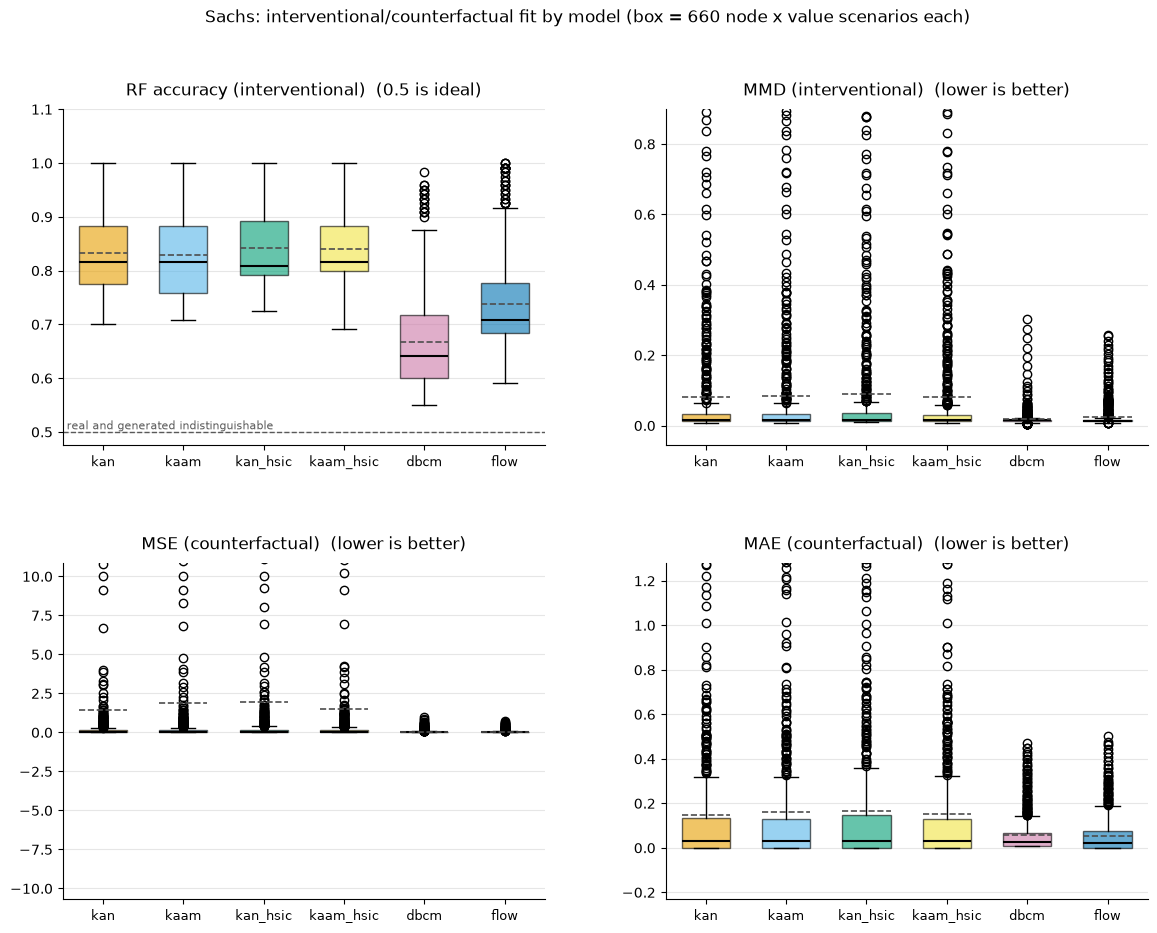


Figure written to C:\Users\aarna\Desktop\clau\TFM Claudia\kacgm-hsic\outputs\sachs_hsic_nonadditive\figures


In [10]:
# ============================================================== Interventional / counterfactual metric box plot
# Box = distribution over the 660 (node, value) intervention scenarios (11 nodes x 60 values in
# cf_vector_values -- see inter_vector / "Generate the SACHS dataset" cell), one box per model,
# using the same rf_acc_int_all / mmd_int_all / mse_cf_all / mae_cf_all lists as the mean +- std
# table above.
#
# Note the variability source here is different from the earlier observational box plot: that one
# draws its 20 points per box from *retraining on 20 different seeds*; this one draws its 660
# points per box from a *single* trained model evaluated under 660 different interventions -- i.e.
# this shows how consistent each model's fit is ACROSS intervention scenarios, not across retrains.
#
# mse_cf/mae_cf (and to a lesser extent mmd_int) are heavily right-skewed -- most scenarios have
# small error but a handful (likely extrapolation near the edges of the +-3 sweep) produce much
# larger errors (e.g. kan family mse_cf: median ~0.01, max ~5.4). The y-axis of each panel is
# therefore capped at the 98th percentile (pooled across models) so the box/whiskers stay legible;
# a few extreme points per model are cut off from view as a result (still counted in the mean +-
# std table above, which is why those stds look large relative to their means).

paleta_modelos = {
    'kan': '#E69F00', 'kaam': '#56B4E9', 'kan_hsic': '#009E73',
    'kaam_hsic': '#F0E442', 'dbcm': '#CC79A7', 'flow': '#0072B2',
}

int_cf_data = {}
for model_name in model_names:
    results_file = os.path.join(data_dir, f"sachs_results_{model_name}.pkl")
    if not os.path.exists(results_file):
        print(f"Results file {results_file} not found.")
        continue
    with open(results_file, 'rb') as f:
        int_cf_data[model_name] = pickle.load(f)

box_model_names = [m for m in model_names if m in int_cf_data]
positions = np.arange(1, len(box_model_names) + 1)
colors = [paleta_modelos[m] for m in box_model_names]

BOX_METRICS_INT_CF = [
    ('rf_acc_int', 'RF accuracy (interventional)', '0.5 is ideal'),
    ('mmd_int',    'MMD (interventional)',          'lower is better'),
    ('mse_cf',     'MSE (counterfactual)',           'lower is better'),
    ('mae_cf',     'MAE (counterfactual)',           'lower is better'),
]

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.ravel()

for ax, (metric, title, direction) in zip(axs, BOX_METRICS_INT_CF):
    box_data = [np.asarray(int_cf_data[m][f'{metric}_all']) for m in box_model_names]
    bplot = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                        showmeans=True, meanline=True,
                        medianprops=dict(color='black', linewidth=1.5),
                        meanprops=dict(color='0.3', linewidth=1.2, linestyle='--'))
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    if metric == 'rf_acc_int':
        ax.axhline(0.5, color='0.35', ls='--', lw=1)
        ax.text(positions[0] - 0.45, 0.5, 'real and generated indistinguishable', va='bottom', ha='left',
                fontsize=8, color='0.35')

    pooled = np.concatenate(box_data)
    ax.set_ylim(top=np.percentile(pooled, 98) * 1.1)

    ax.set_title(f'{title}  ({direction})', fontsize=12, loc='center', pad=10)
    ax.grid(axis='y', color='0.9', lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xticks(positions)
    ax.set_xticklabels(box_model_names, fontsize=9)

fig.suptitle(f'Sachs: interventional/counterfactual fit by model (box = {len(box_data[0])} node x value scenarios each)', fontsize=12, y=1.0)
fig.subplots_adjust(top=0.9, hspace=0.35, wspace=0.25)

fig.savefig(os.path.join(figures_dir, 'sachs_int_cf_metrics_boxplot.pdf'), bbox_inches='tight')
plt.show()

print(f'\nFigure written to {figures_dir}')


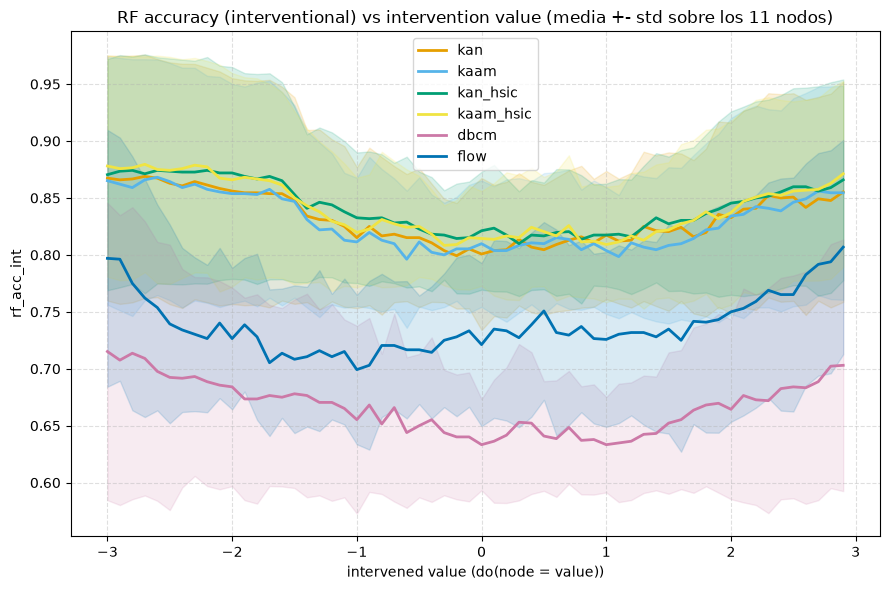

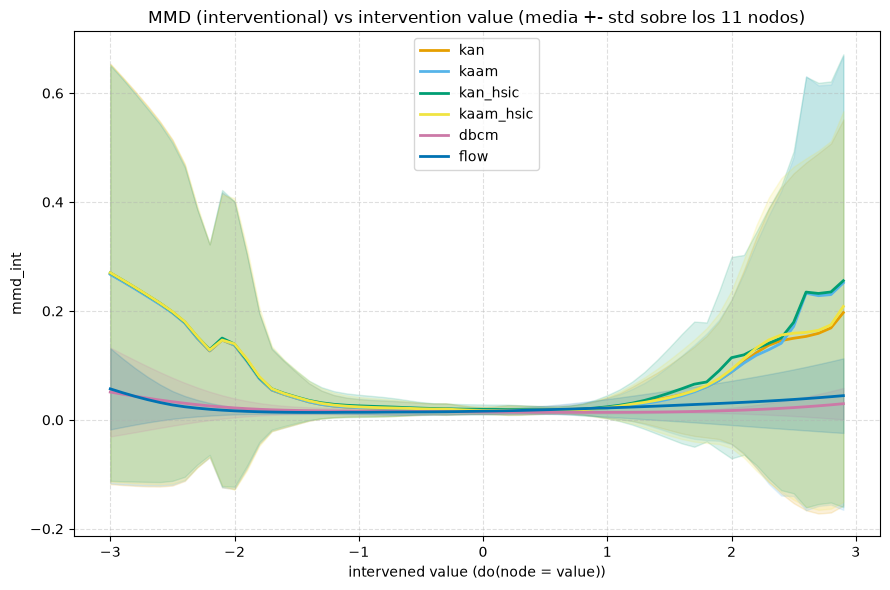

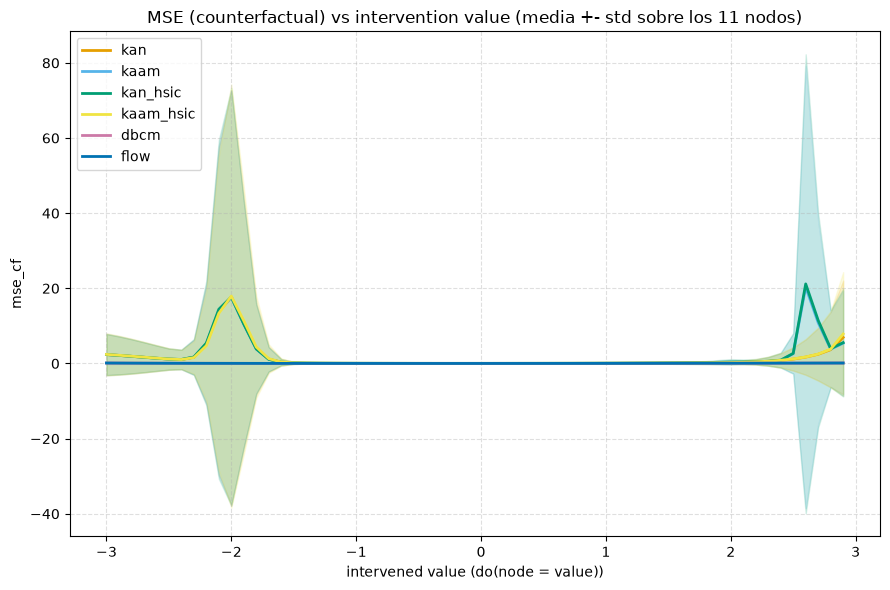

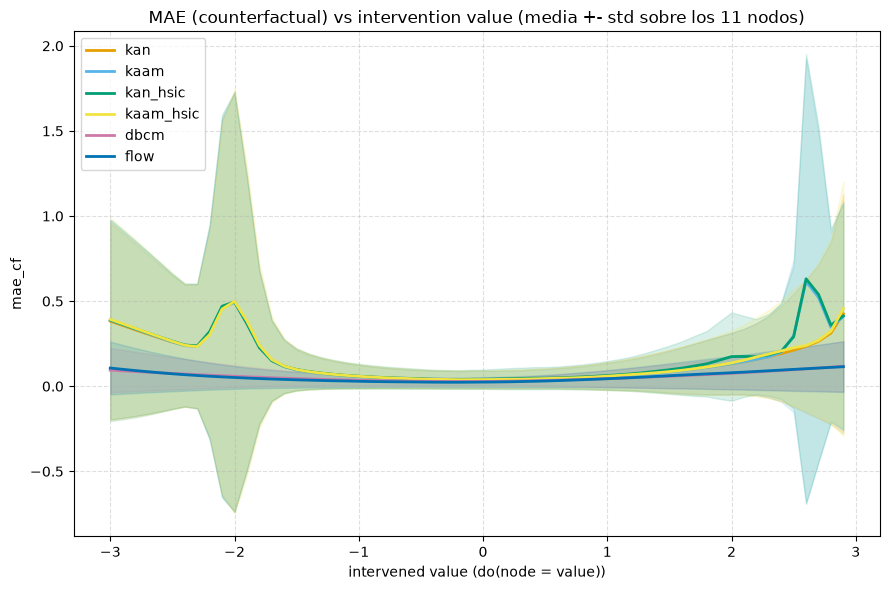

In [11]:
# Same "mean +- std band vs swept x-axis" style as the beta sweep plots above (cell "Grafico
# del barrido de beta"), but here the swept x-axis is the intervention VALUE (cf_vector_values
# -- the inner loop of inter_vector) instead of beta_weight, and at each value the mean/std is
# taken across the 11 nodes that were intervened on with that value (the outer loop of
# inter_vector) instead of across the 20 seeds. One line per model, instead of one per family.
#
# inter_vector[i] = (node, value, cf_eval_df) is in the same order as each model's
# f'{metric}_all' list (both built by iterating inter_vector once in the same order, see
# evaluate_cf in sachs_hsic_beta.ipynb), so zipping the two recovers which (node, value) each
# entry belongs to.
inter_node = np.array([node_ for node_, value_, _ in inter_vector])
inter_value = np.array([value_ for node_, value_, _ in inter_vector])

paleta_modelos_sweep = {
    'kan': '#E69F00', 'kaam': '#56B4E9', 'kan_hsic': '#009E73',
    'kaam_hsic': '#F0E442', 'dbcm': '#CC79A7', 'flow': '#0072B2',
}

sweep_metrics = [
    ('rf_acc_int', 'RF accuracy (interventional)'),
    ('mmd_int',    'MMD (interventional)'),
    ('mse_cf',     'MSE (counterfactual)'),
    ('mae_cf',     'MAE (counterfactual)'),
]

for metric, title in sweep_metrics:
    fig, ax = plt.subplots(figsize=(9, 6))
    for model_name in model_names:
        results_file = os.path.join(data_dir, f"sachs_results_{model_name}.pkl")
        if not os.path.exists(results_file):
            print(f"Results file {results_file} not found.")
            continue
        with open(results_file, 'rb') as f:
            results = pickle.load(f)
        values_all = np.asarray(results[f'{metric}_all'])

        y_mean, y_std = [], []
        for v in cf_vector_values:
            mask = np.isclose(inter_value, v, atol=1e-6)
            y_mean.append(values_all[mask].mean())
            y_std.append(values_all[mask].std())
        y_mean = np.array(y_mean)
        y_std = np.array(y_std)

        color = paleta_modelos_sweep[model_name]
        ax.plot(cf_vector_values, y_mean, linewidth=2, label=model_name, color=color)
        ax.fill_between(cf_vector_values, y_mean - y_std, y_mean + y_std, alpha=0.15, color=color)

    ax.set_xlabel("intervened value (do(node = value))")
    ax.set_ylabel(metric)
    ax.set_title(f"{title} vs intervention value (media +- std sobre los 11 nodos)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, f"sachs_{metric}_intervention_sweep.pdf"), dpi=300, bbox_inches="tight")
    plt.show()
